In [1]:
#other imports
import os
import sys
import numpy as np
#os.chdir('C:/Code/Github/GLM_python-main')
project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
# Import path setup
from utils.path_utils import setup_paths
base_dir = setup_paths()

In [3]:
# Helper functions
from helper_functions.data_trial_plotter import TrialPlotter
from helper_functions.data_trial_divider import TrialDivider

# Core modules
from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
from utils.Plotter import Plotter as plotterfun

from analysis.DecoderAnalyzer import DecoderAnalyzer as analysisdec
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun


# from analysis_code.DataHandlerEncoding import DataHandlerEncoding as datafun
# from analysis_code.Plotter import Plotter as plotterfun
# from analysis_code.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun

In [4]:
#initialize class
data_handler = datafun(data=None)  # Pass any initial data if needed

In [5]:
# LOAD INFO ABOUT DATASETS
info_dir = 'W:\Connie/results\Bassi2025\data' #'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
for dat in datasets:
    print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
# remove_indices = [7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]#range(2,25) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #[2,3,8,18]
# indices_included = [i for i in range(len(datasets)) if i not in remove_indices]
# # Remove indices from both lists
remove_indices = [9]
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]

# Print remaining datasets
for dat in datasets:
    print(f'{dat} loaded')

('HA11-1R', '2023-05-05', 'V:')
('HA11-1R', '2023-04-13', 'V:')
('HA2-1L', '2023-04-12', 'V:')
('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-21', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA10-1L', '2023-04-10', 'V:')
('HA10-1L', '2023-04-17', 'V:')
('HA10-1L', '2023-04-12', 'V:')
('HA11-1R', '2023-04-07', 'V:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-06-27', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-14', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HE4-1L1R', '2023-09-11', 'W:')
('HA10-1L', '2023-03-31', 'V:')
('HE1-00', '2023-05-30', 'V:')
('HA11-1R', '2023-05-05', 'V:') loaded
('HA11-1R', '2023-04-13', 'V:') loaded
('HA2-1L', '2023-04-12', 'V:') loaded
('HA2-1L', '2023-05-05', 'V:') loaded
('HA1-00', '2023-06-29', 'V:') loaded
('HA1-00', '

In [6]:
#LOAD ACTUAL DATASETS (CAN TAKE A WHILE ~50MIN)
save_results = os.path.join(f'W:\Connie/results\Bassi2025\glm_coupling') # os.path.join(f'V:/Connie/results/glm/all_together/updated')
os.makedirs(save_results, exist_ok=True)

model_type = 'GLM_running'
model_info = {
                0: ("model_output_running_active", "poss_model_0_test_context_VR_data_cluster_"), #behavior only model tested in active context
                1: ("model_output_running_passive", "poss_model_0_test_context_passive_data_cluster_") #behavior only model tested in active context
            }

results_pre = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated', models_to_load=[0,1], model_info=model_info) #model_info can be used to specify custom model names and file prefixes if needed

Processing dataset: HA11-1R_2023-05-05
poss_model_0_test_context_VR_data_cluster_0.pkl
poss_model_0_test_context_VR_data_cluster_1.pkl
poss_model_0_test_context_VR_data_cluster_2.pkl
poss_model_0_test_context_VR_data_cluster_3.pkl
poss_model_0_test_context_VR_data_cluster_4.pkl
poss_model_0_test_context_VR_data_cluster_5.pkl
poss_model_0_test_context_VR_data_cluster_6.pkl
poss_model_0_test_context_VR_data_cluster_7.pkl
poss_model_0_test_context_VR_data_cluster_8.pkl
poss_model_0_test_context_VR_data_cluster_9.pkl
poss_model_0_test_context_VR_data_cluster_10.pkl
poss_model_0_test_context_VR_data_cluster_11.pkl
poss_model_0_test_context_VR_data_cluster_12.pkl
poss_model_0_test_context_VR_data_cluster_13.pkl
poss_model_0_test_context_VR_data_cluster_14.pkl
poss_model_0_test_context_VR_data_cluster_15.pkl
poss_model_0_test_context_VR_data_cluster_16.pkl
poss_model_0_test_context_VR_data_cluster_17.pkl
poss_model_0_test_context_VR_data_cluster_18.pkl
poss_model_0_test_context_VR_data_cluste

In [7]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)


In [ ]:
#align the data
from utils.GLMPredictorProcessor import GLMPredictorProcessor as predictorpro  # or whatever name you choose

results = results_pre
model_types = 'GLM_running'  # List your model types / COMBINED
no_abs = 1
model_output_all = 'model_output_running_passive'

_, _, _, _, _,celltype_array, neuron_groups, _ = data_handler.aggregate_model_data_from_results(results, no_abs,model_output_all_input = model_output_all)

predictorfun = predictorpro(neuron_groups=neuron_groups)  # Initialize the class




alignment ={}
alignment['type'] = 'stimulus' #'stimulus' #pre, stimulus
#40sec per dataset
# return_conditions_updated=True adds conditions_updated.mat aligned to the same trials
all_vars, aligned_behav, _, alignment_frames_all, conditions_updated_active = predictorfun.load_and_align_predictors_datasets_running(
    datasets=datasets,
    model_type='GLM_running',
    alignment=alignment,
    save_suffix='VR_',
    return_conditions_updated=True,
)
all_vars_passive, aligned_behav_passive, _, alignment_frames_all_passive, conditions_updated_passive = predictorfun.load_and_align_predictors_datasets_running(
    datasets=datasets,
    model_type='GLM_running',
    alignment=alignment,
    save_suffix='passive_',
    return_conditions_updated=True,
)

#align the neural data (active)
aligned_neural_pred, _ = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all,results_pre, model_type = 'model_output_running_active')
aligned_neural_true, aligned_velocity = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all,results_pre, model_type = 'model_output_running_active', data_dir = 'VR_')

#align the neural data (passive)
aligned_neural_pred_passive, _ = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all_passive,results_pre, model_type = 'model_output_running_passive')
aligned_neural_true_passive, aligned_velocity_passive = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all_passive,results_pre, model_type = 'model_output_running_passive', data_dir = 'passive_')


HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-10
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HE4-1L1R_2023-09-11
HA10-1L_2023-03-31
HE1-00_2023-05-30
Processing dataset: HA11-1R_2023-05-05
Processing dataset: HA11-1R_2023-04-13
Processing dataset: HA2-1L_2023-04-12
Processing dataset: HA2-1L_2023-05-05
Processing dataset: HA1-00_2023-06-29
Processing dataset: HA1-00_2023-08-28
Processing dataset: HE4-1L1R_2023-08-21
Processing dataset: HE4-1L1R_2023-08-24
Processing dataset: HA10-1L_2023-04-10
Processing dataset: HA10-1L_2023-04-12
Processing dataset: HA11-1R_2023-04-07
Processing dataset: HA11-1R_2023-05-01
Processing dataset: HA11-1R_2023-05-02
Processing dataset: HA2-1L_2023-04-28
Proce

In [12]:
frame_subset_to_use = range(0,37)
#Calculate deviance explained for each predictor and overall
analysis_manager = analysisfun(data = None, plotter=plotter)
frac_dev_all, d_model_all, d_null_all = analysis_manager.compute_aligned_frac_dev_all(aligned_neural_true, aligned_neural_pred, loss_type='poisson', frame_subset = frame_subset_to_use,recalibrate_intercept=False)
frac_dev_all_passive, d_model_all_passive, d_null_all_passive = analysis_manager.compute_aligned_frac_dev_all(aligned_neural_true_passive, aligned_neural_pred_passive, loss_type='poisson', frame_subset = frame_subset_to_use,recalibrate_intercept=False)


#plotting
mean_frac_dev_by_key, sem_frac_dev_by_key, mean_frac_dev_plotting, cell_ids_plotting = analysis_manager.average_frac_dev_across_folds(frac_dev_all, cell_ids_dict=None)
mean_frac_dev_by_key_passive, sem_frac_dev_by_key_passive, mean_frac_dev_plotting_passive, cell_ids_plotting =analysis_manager.average_frac_dev_across_folds(frac_dev_all_passive, cell_ids_dict=None)

current dataset HA11-1R_2023-05-05
current dataset HA11-1R_2023-04-13
current dataset HA2-1L_2023-04-12
current dataset HA2-1L_2023-05-05
current dataset HA1-00_2023-06-29
current dataset HA1-00_2023-08-28
current dataset HE4-1L1R_2023-08-21
current dataset HE4-1L1R_2023-08-24
current dataset HA10-1L_2023-04-10
current dataset HA10-1L_2023-04-12
current dataset HA11-1R_2023-04-07
current dataset HA11-1R_2023-05-01
current dataset HA11-1R_2023-05-02
current dataset HA2-1L_2023-04-28
current dataset HA2-1L_2023-05-01
current dataset HA1-00_2023-06-27
current dataset HA1-00_2023-07-07
current dataset HA1-00_2023-08-25
current dataset HE4-1L1R_2023-08-14
current dataset HE4-1L1R_2023-08-28
current dataset HE4-1L1R_2023-09-04
current dataset HE4-1L1R_2023-09-11
current dataset HA10-1L_2023-03-31
current dataset HE1-00_2023-05-30
current dataset HA11-1R_2023-05-05
current dataset HA11-1R_2023-04-13
current dataset HA2-1L_2023-04-12
current dataset HA2-1L_2023-05-05
current dataset HA1-00_202

Intercept-recalibrated FDE matches the mean predicted rate to the mean observed rate within each tested context/window, preserving temporal structure. This is a bias-control and should not replace raw FDE.


In [13]:
# Intercept-recalibrated aligned FDE (bias-control; does not replace raw FDE above)
frac_dev_all_recal, d_model_all_recal, d_null_all_recal = analysis_manager.compute_aligned_frac_dev_all(
    aligned_neural_true,
    aligned_neural_pred,
    loss_type='poisson',
    frame_subset=frame_subset_to_use,
    recalibrate_intercept=True,
)
frac_dev_all_passive_recal, d_model_all_passive_recal, d_null_all_passive_recal = analysis_manager.compute_aligned_frac_dev_all(
    aligned_neural_true_passive,
    aligned_neural_pred_passive,
    loss_type='poisson',
    frame_subset=frame_subset_to_use,
    recalibrate_intercept=True,
)

mean_frac_dev_by_key_recal, sem_frac_dev_by_key_recal, mean_frac_dev_plotting_recal, _ = analysis_manager.average_frac_dev_across_folds(
    frac_dev_all_recal, cell_ids_dict=None
)
mean_frac_dev_by_key_passive_recal, sem_frac_dev_by_key_passive_recal, mean_frac_dev_plotting_passive_recal, _ = analysis_manager.average_frac_dev_across_folds(
    frac_dev_all_passive_recal, cell_ids_dict=None
)

print('Recalibrated active neurons (concat):', mean_frac_dev_plotting_recal.shape)
print('Recalibrated passive neurons (concat):', mean_frac_dev_plotting_passive_recal.shape)


current dataset HA11-1R_2023-05-05
current dataset HA11-1R_2023-04-13
current dataset HA2-1L_2023-04-12
current dataset HA2-1L_2023-05-05
current dataset HA1-00_2023-06-29
current dataset HA1-00_2023-08-28
current dataset HE4-1L1R_2023-08-21
current dataset HE4-1L1R_2023-08-24
current dataset HA10-1L_2023-04-10
current dataset HA10-1L_2023-04-12
current dataset HA11-1R_2023-04-07
current dataset HA11-1R_2023-05-01
current dataset HA11-1R_2023-05-02
current dataset HA2-1L_2023-04-28
current dataset HA2-1L_2023-05-01
current dataset HA1-00_2023-06-27
current dataset HA1-00_2023-07-07
current dataset HA1-00_2023-08-25
current dataset HE4-1L1R_2023-08-14
current dataset HE4-1L1R_2023-08-28
current dataset HE4-1L1R_2023-09-04
current dataset HE4-1L1R_2023-09-11
current dataset HA10-1L_2023-03-31
current dataset HE1-00_2023-05-30
current dataset HA11-1R_2023-05-05
current dataset HA11-1R_2023-04-13
current dataset HA2-1L_2023-04-12
current dataset HA2-1L_2023-05-05
current dataset HA1-00_202

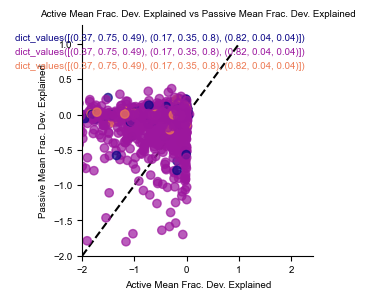

In [14]:
#get dataset cell types
cell_types = {
                0: 'pyr',
                1: 'som',
                2: 'pv',
            }
cell_labels = []
# Loop over each dataset in the results dictionary
for dataset_key, dataset in results_pre.items():
    # if significant_neurons and dataset_key in significant_neurons:
    #             cell_ids = significant_neurons[dataset_key][0]
    # else:
    cell_ids = range(len(dataset['celltype_array']))  # Default to all cells
    cell_labels.extend([cell_types[dataset['celltype_array'][i]] for i in cell_ids])
    
plotter.scatter_model_dev_comparison(mean_frac_dev_plotting_passive,mean_frac_dev_plotting,  cell_labels,measure_string = 'Active Mean Frac. Dev. Explained', measure_string2='Passive Mean Frac. Dev. Explained', plot_lims_neg = -2, minmax = (-2,1))

In [15]:
import os
import numpy as np
import scipy.io


def load_sound_opto_data_test(dir, set_diff=True, exclude=None):
    """
    Loads neuron IDs and modulation indices for sound and optogenetic conditions.

    Sound can have more datasets than opto. If opto is missing the last dataset,
    sound is still loaded for that dataset.
    """

    # ---------------------------------------------------------
    # Load opto data
    # ---------------------------------------------------------
    mat_data = scipy.io.loadmat(os.path.join(dir, "opto.mat"))
    opto = mat_data["opto"][0][0]
    opto = data_handler.unwrap_matlab(opto)

    # Make opto sig_cells have same orientation as sound
    opto["sig_cells"] = opto["sig_cells"].T

    # ---------------------------------------------------------
    # Load sound data
    # ---------------------------------------------------------
    mat_data = scipy.io.loadmat(os.path.join(dir, "sound.mat"))
    sound = mat_data["sound"][0][0]
    sound = data_handler.unwrap_matlab(sound)

    # ---------------------------------------------------------
    # Load info
    # ---------------------------------------------------------
    mat_data = scipy.io.loadmat(os.path.join(dir, "info.mat"))
    info = mat_data["info"][0][0]

    mouse_dates_all = [
        item[0].replace("\\", "_").replace("/", "_")
        for item in info["mouse_date"][0]
    ]

    n_sound = sound["sig_cells"].shape[1]
    n_opto = opto["sig_cells"].shape[1]

    mouse_dates_sound = mouse_dates_all[:n_sound]
    mouse_dates_opto = mouse_dates_all[:n_opto]

    # ---------------------------------------------------------
    # Exclude datasets
    # ---------------------------------------------------------
    if exclude is not None:

        if not isinstance(exclude, (list, tuple)):
            exclude = [exclude]

        exclude_sound_idx = []
        exclude_opto_idx = []

        for ex in exclude:
            if isinstance(ex, int):
                if ex < len(mouse_dates_sound):
                    exclude_sound_idx.append(ex)
                if ex < len(mouse_dates_opto):
                    exclude_opto_idx.append(ex)

            elif isinstance(ex, str):
                if ex in mouse_dates_sound:
                    exclude_sound_idx.append(mouse_dates_sound.index(ex))
                if ex in mouse_dates_opto:
                    exclude_opto_idx.append(mouse_dates_opto.index(ex))

        keep_sound_idx = [
            i for i in range(len(mouse_dates_sound))
            if i not in exclude_sound_idx
        ]

        keep_opto_idx = [
            i for i in range(len(mouse_dates_opto))
            if i not in exclude_opto_idx
        ]

        mouse_dates_sound = [mouse_dates_sound[i] for i in keep_sound_idx]
        mouse_dates_opto = [mouse_dates_opto[i] for i in keep_opto_idx]

        sound["sig_cells"] = sound["sig_cells"][:, keep_sound_idx]
        sound["mod"] = sound["mod"][keep_sound_idx, :]

        opto["sig_cells"] = opto["sig_cells"][:, keep_opto_idx]
        opto["mod"] = opto["mod"][keep_opto_idx, :]

        print("Keeping sound datasets:", keep_sound_idx)
        print("Keeping opto datasets:", keep_opto_idx)
        print("Excluding sound datasets:", exclude_sound_idx)
        print("Excluding opto datasets:", exclude_opto_idx)

    # Map opto dates to opto index
    opto_date_to_idx = {
        mouse_date: idx
        for idx, mouse_date in enumerate(mouse_dates_opto)
    }

    # ---------------------------------------------------------
    # Process neurons
    # ---------------------------------------------------------
    significant_neurons = {}
    mod_indices = {}

    sound_separated = {
        "sig_cells_pos": np.empty((1, len(mouse_dates_sound)), dtype=object),
        "sig_cells_neg": np.empty((1, len(mouse_dates_sound)), dtype=object),
    }

    for sound_idx, mouse_date in enumerate(mouse_dates_sound):

        significant_neurons[mouse_date] = {}
        mod_indices[mouse_date] = {}

        # -----------------------------------------------------
        # Sound significant cells
        # -----------------------------------------------------
        sound_neurons = sound["sig_cells"][0, sound_idx] - 1
        sound_neurons = np.asarray(sound_neurons).astype(int).ravel()

        sound["sig_cells"][0, sound_idx] = sound_neurons

        # -----------------------------------------------------
        # Optional opto significant cells
        # -----------------------------------------------------
        has_opto = mouse_date in opto_date_to_idx

        if has_opto:
            opto_idx = opto_date_to_idx[mouse_date]

            opto_neurons = opto["sig_cells"][0, opto_idx] - 1
            opto_neurons = np.asarray(opto_neurons).astype(int).ravel()

            opto["sig_cells"][0, opto_idx] = opto_neurons
        else:
            opto_idx = None
            opto_neurons = np.array([], dtype=int)

        # -----------------------------------------------------
        # Modulation indices
        # -----------------------------------------------------
        if has_opto:
            for context in range(opto["mod"].shape[1]):
                mod_indices[mouse_date][context] = {}
                mod_indices[mouse_date][context]["opto"] = opto["mod"][opto_idx, context]

        for context in range(sound["mod"].shape[1]):
            if context not in mod_indices[mouse_date]:
                mod_indices[mouse_date][context] = {}

            mod_indices[mouse_date][context]["sound"] = sound["mod"][sound_idx, context]

        # -----------------------------------------------------
        # Total neurons, based on sound data
        # -----------------------------------------------------
        all_neurons = list(range(sound["mod"][sound_idx, 0].shape[0]))

        # -----------------------------------------------------
        # Sound positive / negative
        # -----------------------------------------------------
        mod0 = sound["mod"][sound_idx, 0]
        mod1 = sound["mod"][sound_idx, 1]

        sound_sig_pos = [
            int(n) for n in sound_neurons
            if mod0[n] > 0 and mod1[n] > 0
        ]

        sound_sig_neg = [
            int(n) for n in sound_neurons
            if mod0[n] < 0 and mod1[n] < 0
        ]

        # -----------------------------------------------------
        # Sound / opto categories
        # -----------------------------------------------------
        if set_diff:
            sound_only = list(set(sound_neurons) - set(opto_neurons))
            opto_only = list(set(opto_neurons) - set(sound_neurons))
        else:
            sound_only = list(sound_neurons)
            opto_only = list(opto_neurons)

        significant_neurons[mouse_date]["opto"] = opto_only
        significant_neurons[mouse_date]["sound"] = sound_only
        significant_neurons[mouse_date]["sound_pos"] = sound_sig_pos
        significant_neurons[mouse_date]["sound_neg"] = sound_sig_neg

        significant_neurons[mouse_date]["both"] = list(
            set(opto_neurons).intersection(set(sound_neurons))
        )

        significant_neurons[mouse_date]["unmod"] = list(
            set(all_neurons)
            - set(opto_neurons)
            - set(sound_neurons)
        )

        sound_separated["sig_cells_pos"][0, sound_idx] = sound_sig_pos
        sound_separated["sig_cells_neg"][0, sound_idx] = sound_sig_neg

    return (
        opto,
        sound,
        mouse_dates_sound,
        significant_neurons,
        mod_indices,
        sound_separated,
    )

opto, sound, mouse_dates, significant_neurons, mod_indices, sound_separated = load_sound_opto_data_test('W:\Connie/results\Bassi2025\data', set_diff = True, exclude = ["HA10-1L_2023-04-17"])# exclude = "HE1-00_2023-05-30")

Keeping sound datasets: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Keeping opto datasets: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Excluding sound datasets: [9]
Excluding opto datasets: [9]


In [180]:
#load opto/sound neurons
opto, sound, mouse_dates, significant_neurons, mod_indices, sound_separated = data_handler.load_sound_opto_data('W:\Connie/results\Bassi2025\data', set_diff = True, exclude = ["HA10-1L_2023-04-17"])# exclude = "HE1-00_2023-05-30")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


Plots of mean FDE compared across contexts

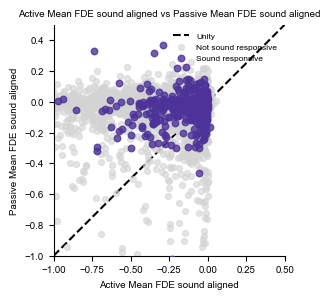

(array([-0.05787074, -0.30997016, -0.31515263, ..., -0.22172623,
        -0.04536044, -0.14334109]),
 array([-0.00867286,  0.00446482, -0.00607146, ...,  0.08676029,
        -0.0010886 , -0.0546423 ]),
 array([ True, False, False, ..., False, False, False]))

In [16]:
plotter.scatter_dev_active_passive_sound_sig(mean_frac_dev_by_key, mean_frac_dev_by_key_passive, datasets, sound_separated,sig_type = 'sig_cells_pos', measure_string = 'Active Mean FDE sound aligned', measure_string2='Passive Mean FDE sound aligned',  plot_lims = 0.5, plot_lims_neg = -1)

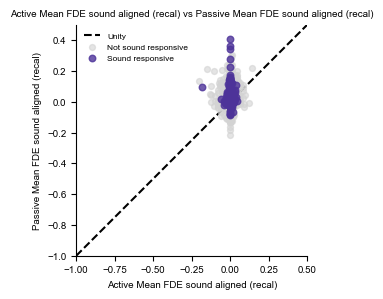

(array([ 1.35106218e-02, -5.19399706e-03, -9.90819229e-03, ...,
        -1.29929574e-06,  3.07166011e-05,  1.91861562e-05]),
 array([ 0.00141371,  0.01387069,  0.00798219, ...,  0.10174606,
         0.00434035, -0.0346776 ]),
 array([ True, False, False, ..., False, False, False]))

In [17]:
#plotting baseline recalibrated data
plotter.scatter_dev_active_passive_sound_sig(mean_frac_dev_by_key_recal, mean_frac_dev_by_key_passive_recal, datasets, sound_separated,sig_type = 'sig_cells_pos', measure_string = 'Active Mean FDE sound aligned (recal)', measure_string2='Passive Mean FDE sound aligned (recal)',  plot_lims = 0.5, plot_lims_neg = -1)

Plot FDE using all frames! (no alignment)

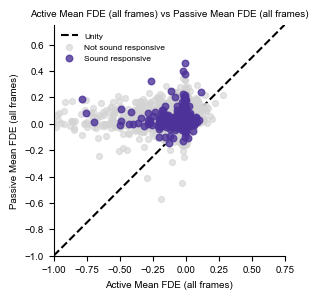

(array([-0.03814499, -0.09186077, -0.04516037, ..., -0.01398579,
        -0.0510822 , -0.05410964]),
 array([-0.00491516,  0.00308191,  0.00258705, ...,  0.08368975,
        -0.00520413,  0.03060282]),
 array([ True, False, False, ..., False, False, False]))

In [18]:

mean_frac_dev_by_key_all = {}
mean_frac_dev_by_key_passive_all = {}

for ds in datasets:
    animal, date, server = ds  # server ignored for lookup

    key = f"{animal}_{date}"

    mean_frac_dev_by_key_all[key] = results_pre[key]['mean_dev_0']
    mean_frac_dev_by_key_passive_all[key] = results_pre[key]['mean_dev_1']


plotter.scatter_dev_active_passive_sound_sig(
    mean_frac_dev_by_key_all,
    mean_frac_dev_by_key_passive_all,
    datasets,
    sound_separated,
    sig_type='sig_cells_pos',
    plot_lims=0.75,
    plot_lims_neg=-1,
    measure_string = 'Active Mean FDE (all frames)', 
    measure_string2='Passive Mean FDE (all frames)'
)

Compute Modulation index in predicted vs true data (using all trials! so it includes photostim trials)

In [48]:
# Sound modulation index (v1): S1-relative pre/post windows on aligned true vs running-only pred
from analysis.ModulationIndexAnalyzer import ModulationIndexAnalyzer
import matplotlib.pyplot as plt

s1_onset_frame = 6
pre_frames = np.arange(0,5) #np.arange(0, s1_onset_frame)                      # frames 0..5
post_frames = np.arange(13,43) #np.arange(s1_onset_frame + 2, s1_onset_frame + 32)  # frames 8..37
mi_analyzer = ModulationIndexAnalyzer(

    pre_frames=pre_frames,
    post_frames=post_frames,
    n_shuffles=1000,   # raise to 10000 to match Bassirunyan default
    alpha=0.05,
    eps=1e-12,
    random_state=0,
)

# Fold-averaged MI (no per-fold p averaging). Optional pooled bootstrap for dataset-level p.
mi_active = mi_analyzer.compute_mi_true_vs_pred(
    aligned_neural_true,
    aligned_neural_pred,
    compute_p=False,
    pooled_bootstrap=False,
)

print('pre_frames:', pre_frames)
print('post_frames:', post_frames)
print('n datasets (active):', len(mi_active['comparison']))


# Cell-type labels from results[key]["celltype_array"] (0=PYR, 1=SOM, 2=PV)

cell_type_dict = plotter.make_cell_type_dict_from_results(
    results,
    mi_reference_dict=mi_active['true']['mi_mean_by_key'],
    label_map={0: "PYR", 1: "SOM", 2: "PV"},
    celltype_key="celltype_array",
)
print("example cell types:", np.unique(cell_type_dict[next(iter(cell_type_dict))]))




pre_frames: [0 1 2 3 4]
post_frames: [13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36
 37 38 39 40 41 42]
n datasets (active): 24
example cell types: ['PV' 'PYR' 'SOM']


Modulation index plots

Active true vs pred MI Pearson r = 0.113 (n=7450 neurons)


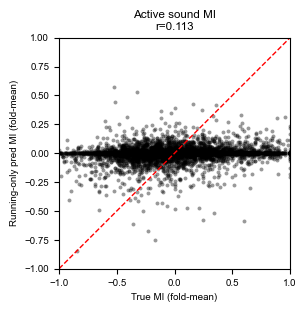

Passive true vs pred MI Pearson r = 0.064 (n=7450 neurons)


In [41]:
# Compare fold-averaged true vs predicted sound MI (active)
mi_true_all = []
mi_pred_all = []
for key, comp in mi_active['comparison'].items():
    mi_true_all.append(comp['mi_true_mean'])
    mi_pred_all.append(comp['mi_pred_mean'])

mi_true_all = np.concatenate(mi_true_all)
mi_pred_all = np.concatenate(mi_pred_all)
finite = np.isfinite(mi_true_all) & np.isfinite(mi_pred_all)

r = np.corrcoef(mi_true_all[finite], mi_pred_all[finite])[0, 1]
print(f'Active true vs pred MI Pearson r = {r:.3f} (n={finite.sum()} neurons)')

lim = np.nanmax(np.abs(np.concatenate([mi_true_all[finite], mi_pred_all[finite]])))
lim = max(lim, 0.1)

fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(mi_true_all[finite], mi_pred_all[finite], s=8, alpha=0.4, c='k', linewidths=0)
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax.set_xlabel('True MI (fold-mean)')
ax.set_ylabel('Running-only pred MI (fold-mean)')
ax.set_title(f'Active sound MI\nr={r:.3f}')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
plt.show()

# Optional: same MI pipeline on passive aligned true/pred
mi_passive = mi_analyzer.compute_mi_true_vs_pred(
    aligned_neural_true_passive,
    aligned_neural_pred_passive,
    compute_p=False,
    pooled_bootstrap=False,
)

mi_true_pas = np.concatenate([c['mi_true_mean'] for c in mi_passive['comparison'].values()])
mi_pred_pas = np.concatenate([c['mi_pred_mean'] for c in mi_passive['comparison'].values()])
finite_pas = np.isfinite(mi_true_pas) & np.isfinite(mi_pred_pas)
r_pas = np.corrcoef(mi_true_pas[finite_pas], mi_pred_pas[finite_pas])[0, 1]
print(f'Passive true vs pred MI Pearson r = {r_pas:.3f} (n={finite_pas.sum()} neurons)')

# Optional dataset-level significance (pooled trials across folds; slow if n_shuffles is large, takes about 5 second for 100 shuffles):
# mi_active_boot = mi_analyzer.compute_mi_true_vs_pred(
#     aligned_neural_true, aligned_neural_pred,
#     compute_p=False, pooled_bootstrap=True, n_shuffles=100,
# )

Sound-responsive MI summary plots (true vs running-only predicted). Masks come from loaded MATLAB `sound` / `sound_separated`; they are not recomputed from GLM predictions.


In [42]:
# Fold-mean MI dicts and MATLAB sound-responsive masks
mi_true_active = mi_active['true']['mi_mean_by_key']
mi_pred_active = mi_active['pred']['mi_mean_by_key']
mi_true_passive = mi_passive['true']['mi_mean_by_key']
mi_pred_passive = mi_passive['pred']['mi_mean_by_key']

n_neurons_by_key = {key: np.asarray(vals).shape[0] for key, vals in mi_true_active.items()}

# sig_cells lives on `sound`; pos/neg live on `sound_separated`
sound_responsive_mask_dict = plotter.make_sound_mask_dict(
    sound, datasets, mask_name='sig_cells', n_neurons_by_key=n_neurons_by_key
)
positive_sound_mask_dict = plotter.make_sound_mask_dict(
    sound_separated, datasets, mask_name='sig_cells_pos', n_neurons_by_key=n_neurons_by_key
)
negative_sound_mask_dict = plotter.make_sound_mask_dict(
    sound_separated, datasets, mask_name='sig_cells_neg', n_neurons_by_key=n_neurons_by_key
)

print('n datasets with sound masks:', len(sound_responsive_mask_dict))
print('example key:', next(iter(sound_responsive_mask_dict)))
print('n sound-responsive (example):', int(sound_responsive_mask_dict[next(iter(sound_responsive_mask_dict))].sum()))


n datasets with sound masks: 24
example key: HA11-1R_2023-05-05
n sound-responsive (example): 106


In [43]:
datasets_opto = datasets[:-1]  # Exclude last dataset for opto

In [44]:
n_neurons_by_key_opto = n_neurons_by_key
# Remove the last dataset
n_neurons_by_key_opto.pop('HE1-00_2023-05-30')

340

In [45]:
opto_responsive_mask_dict = plotter.make_sound_mask_dict(
    opto, datasets_opto, mask_name='sig_cells', n_neurons_by_key=n_neurons_by_key_opto
)


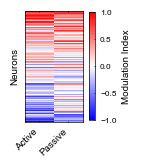

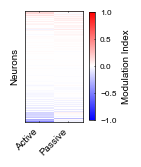

In [46]:
# True vs predicted active/passive MI heatmaps for sound-responsive neurons
os.makedirs('W:/Connie/results/Bassi2025/glm_results/modulation_index', exist_ok=True)
_ = plotter.plot_mi_heatmap_by_context(
    [mi_true_active, mi_true_passive],
    ['Active', 'Passive'],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=-1,
    vmax=1,
    title=None,#'True MI (sound-responsive)',
    datasets=datasets,
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_true_mi_sound_responsive_neurons.pdf',
    figsize = (1.4 , 1.7)
)
_ = plotter.plot_mi_heatmap_by_context(
    [mi_pred_active, mi_pred_passive],
    ['Active', 'Passive'],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=-1,
    vmax=1,
    title=None,#'Running-only predicted MI (same neurons)',
    datasets=datasets,
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_predicted_mi_sound_responsive_neurons.pdf',
    figsize = (1.4 , 1.7)
)


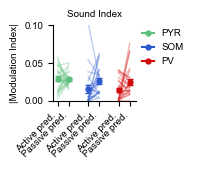

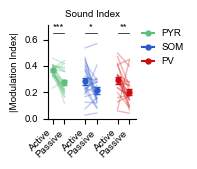

In [49]:
#scatter summary plots of Sound MI
summary_mi_celltype = plotter.summarize_abs_mi_by_dataset(
    mi_context_dicts=[mi_pred_active, mi_pred_passive],
    context_labels=["Active pred.", "Passive pred."],
    neuron_mask_dict=sound_responsive_mask_dict,
    cell_type_dict=cell_type_dict,
    datasets=datasets,
)

stats_mi_pred_act_pass = plotter.compute_paired_context_stats(
    summary_df=summary_mi_celltype,
    metric_col="mean_abs_mi",
    context_a="Active pred.",
    context_b="Passive pred.",
    group_col="cell_type",
    n_permutations=10000,
)
fig, ax = plotter.plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_mi_celltype,
    metric_col="mean_abs_mi",
    context_order=["Active pred.", "Passive pred."],
    cell_type_order=["PYR", "SOM", "PV"],
    title="Sound Index",
    ylabel="|Modulation Index|",
    ylim=(0,.1),
    show_stats=True,
    stats_df=stats_mi_pred_act_pass,
    save_path = 'W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_predicted_sound_index_celltype.pdf',
    show_celltype_labels=False,
    show_celltype_legend=True,
    figsize=(2,1.7)
    
)

## true values 
summary_mi_celltype = plotter.summarize_abs_mi_by_dataset(
    mi_context_dicts=[mi_true_active, mi_true_passive],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    cell_type_dict=cell_type_dict,
    datasets=datasets,
)

stats_mi_tru_act_pass = plotter.compute_paired_context_stats(
    summary_df=summary_mi_celltype,
    metric_col="mean_abs_mi",
    context_a="Active",
    context_b="Passive",
    group_col="cell_type",
    n_permutations=10000,
)
fig, ax = plotter.plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_mi_celltype,
    metric_col="mean_abs_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title="Sound Index",
    ylabel="|Modulation Index|",
    ylim=(0,.65),
    show_stats=True,
    stats_df=stats_mi_tru_act_pass,
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_true_sound_index_celltype.pdf',
    show_celltype_labels=False,
    show_celltype_legend=True,
    figsize=(2,1.7)
    
)

Post-pre delta (numerator-only) and cell-type grouped summaries. Delta uses the same windows/folds as MI: `post_mean - pre_mean`, without dividing by `post + pre`. Sound-responsive masks are unchanged.


In [50]:
# Active true vs running-only predicted post-pre delta (same windows as MI)
delta_active = mi_analyzer.compute_delta_true_vs_pred(
    aligned_true=aligned_neural_true,
    aligned_pred=aligned_neural_pred,
    average_folds=True,
)
delta_true_active = delta_active["true"]
delta_pred_active = delta_active["pred"]

delta_passive = mi_analyzer.compute_delta_true_vs_pred(
    aligned_true=aligned_neural_true_passive,
    aligned_pred=aligned_neural_pred_passive,
    average_folds=True,
)
delta_true_passive = delta_passive["true"]
delta_pred_passive = delta_passive["pred"]
print("n datasets with delta:", len(delta_true_passive))


n datasets with delta: 24


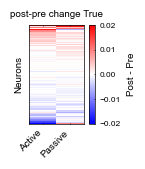

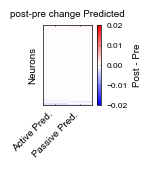

In [52]:
# Delta heatmap, same style as MI (custom limits/label)
fig, ax, delta_matrix,_ = plotter.plot_mi_heatmap_by_context(
    mi_context_dicts=[delta_true_active, delta_true_passive],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=-0.02,
    vmax=0.02,
    title="post-pre change True",
    colorbar_label="Post - Pre",
    datasets=datasets,
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_true_delta_mi_sound_responsive_neurons.pdf',
    figsize = (1.4 , 1.7)
)

fig, ax, delta_matrix,_ = plotter.plot_mi_heatmap_by_context(
    mi_context_dicts=[delta_pred_active, delta_pred_passive],
    context_labels=["Active Pred.", "Passive Pred."],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=-0.02,
    vmax=0.02,
    title="post-pre change Predicted",
    colorbar_label="Post - Pre",
    datasets=datasets,
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_predicted_delta_mi_sound_responsive_neurons.pdf',
    figsize = (1.4 , 1.7)
)


## Condition-aware modulation (sound-only MI + control/opto MI)

Uses ``conditions_updated.mat`` loaded with alignment (rows: sound side, photostim, correct).
Sound-only MI excludes photostim trials. Control MI compares sound+stim vs sound-alone in the **post** window only (Bassirunyan ``compute_mod_index_ctrl``).


In [53]:
# Sound-only MI (photostim == 0), active and passive, true and predicted
mi_true_active_sound_only = mi_analyzer.compute_mi_across_folds(
    aligned_dict=aligned_neural_true,
    conditions_dict=conditions_updated_active,
    trial_selector="sound_no_stim",
    compute_p=False,
)["mi_mean_by_key"]

mi_true_passive_sound_only = mi_analyzer.compute_mi_across_folds(
    aligned_dict=aligned_neural_true_passive,
    conditions_dict=conditions_updated_passive,
    trial_selector="sound_no_stim",
    compute_p=False,
)["mi_mean_by_key"]

mi_pred_active_sound_only = mi_analyzer.compute_mi_across_folds(
    aligned_dict=aligned_neural_pred,
    conditions_dict=conditions_updated_active,
    trial_selector="sound_no_stim",
    compute_p=False,
)["mi_mean_by_key"]

mi_pred_passive_sound_only = mi_analyzer.compute_mi_across_folds(
    aligned_dict=aligned_neural_pred_passive,
    conditions_dict=conditions_updated_passive,
    trial_selector="sound_no_stim",
    compute_p=False,
)["mi_mean_by_key"]

print("sound-only MI keys (true active):", list(mi_true_active_sound_only.keys())[:3])


sound-only MI keys (true active): ['HA11-1R_2023-05-05', 'HA11-1R_2023-04-13', 'HA2-1L_2023-04-12']


In [54]:
# Control/opto MI: (post_sound_stim - post_sound_only) / (post_sound_stim + post_sound_only)
ctrl_mi_true_active = mi_analyzer.compute_control_mod_index_across_folds(
    aligned_dict=aligned_neural_true,
    conditions_dict=conditions_updated_active,
    average_folds=True,
)
ctrl_mi_true_passive = mi_analyzer.compute_control_mod_index_across_folds(
    aligned_dict=aligned_neural_true_passive,
    conditions_dict=conditions_updated_passive,
    average_folds=True,
)
ctrl_mi_pred_active = mi_analyzer.compute_control_mod_index_across_folds(
    aligned_dict=aligned_neural_pred,
    conditions_dict=conditions_updated_active,
    average_folds=True,
)
ctrl_mi_pred_passive = mi_analyzer.compute_control_mod_index_across_folds(
    aligned_dict=aligned_neural_pred_passive,
    conditions_dict=conditions_updated_passive,
    average_folds=True,
)

print("ctrl MI keys (true active):", list(ctrl_mi_true_active.keys())[:3])


ctrl MI keys (true active): ['HA11-1R_2023-05-05', 'HA11-1R_2023-04-13', 'HA2-1L_2023-04-12']


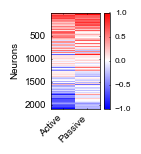

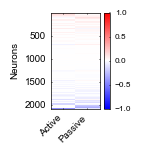

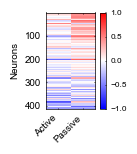

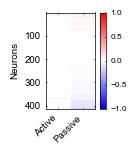

(<Figure size 135x155 with 2 Axes>,
 <Axes: ylabel='Neurons'>,
 array([[-4.53716680e-02,  3.76588370e-01],
        [-1.89468531e-02,  2.96518954e-01],
        [-1.16495353e-02,  2.54517741e-01],
        [-1.13240272e-05,  1.83119335e-01],
        [ 5.29963443e-03,  1.59598010e-01],
        [ 5.04452419e-02,  9.61225201e-02],
        [-3.16241865e-03,  1.30183421e-01],
        [-6.70668392e-03,  1.20491885e-01],
        [-6.05796870e-03,  1.18016453e-01],
        [-1.16912865e-04,  9.82295863e-02],
        [ 4.39468327e-02,  4.53382035e-02],
        [ 2.82747822e-02,  5.87554248e-02],
        [-2.09587273e-02,  1.02542154e-01],
        [ 3.60655322e-02,  4.08584058e-02],
        [ 3.07464199e-02,  4.16675466e-02],
        [ 2.16459091e-02,  4.57897977e-02],
        [ 1.90670723e-04,  6.48975655e-02],
        [-3.21168350e-03,  6.57684655e-02],
        [ 3.10901845e-04,  5.90562155e-02],
        [-1.22609597e-02,  6.97736438e-02],
        [-2.73911998e-03,  5.89342227e-02],
        [-1.3

In [134]:
import matplotlib as mpl
import matplotlib.pyplot as plt
def plot_mi_heatmap_by_context(
        mi_context_dicts,
        context_labels,
        neuron_mask_dict=None,
        sort_context_index=0,
        vmin=-0.4,
        vmax=0.4,
        title=None,
        save_path=None,
        datasets=None,
        cmap="RdBu_r",
        colorbar_label="Modulation Index",
        ylabel = 'Neurons',
        ytick_mode = 'none',
        ytick_step=None,
        figsize = (1.4 + 0.9, 4.2),
        cbar_fraction=0.09,
        cbar_pad=0.08,
        cbar_labelpad=4,
        neuron_order = None
    ):
        """Heatmap of a neuron-wise metric across contexts (rows=neurons).

        Works for MI or post-pre delta. Neurons are concatenated across datasets
        and sorted by ``sort_context_index`` (int or sequence of column indices).
        """
        if len(mi_context_dicts) != len(context_labels):
            raise ValueError("mi_context_dicts and context_labels must have the same length")

        plt.rcParams.update({"font.size": 7, "font.family": "arial"})
        mpl.rcParams["pdf.fonttype"] = 42

        keys = plotter._ordered_dataset_keys(mi_context_dicts, datasets=datasets)
        per_context = [[] for _ in mi_context_dicts]
        for key in keys:
            selected = [
                plotter._selected_mi_for_dataset(d[key], neuron_mask_dict, key)
                for d in mi_context_dicts
            ]
            n = selected[0].shape[0]
            for arr in selected[1:]:
                if arr.shape[0] != n:
                    raise ValueError(
                        f"Selected neuron counts differ across contexts for {key!r}"
                    )
            for i, arr in enumerate(selected):
                per_context[i].append(arr)

        if not per_context[0]:
            raise ValueError("No neurons available to plot")

        mi_matrix = np.column_stack(
            [np.concatenate(vals) for vals in per_context]
        )
        if np.isscalar(sort_context_index):
            sort_vals = mi_matrix[:, int(sort_context_index)]
        else:
            sort_idx = np.asarray(sort_context_index)
            if sort_idx.size == 1:
                sort_vals = mi_matrix[:, int(sort_idx.ravel()[0])]
            else:
                sort_vals = np.nanmean(mi_matrix[:, sort_idx], axis=1)
        order = np.argsort(np.nan_to_num(sort_vals, nan=-np.inf))[::-1]
        mi_sorted = mi_matrix[order, :]

        if neuron_order is not None:
            mi_matrix = mi_matrix[neuron_order, :]
        else:
            # Your existing sorting code
            order = np.argsort(
                np.nan_to_num(sort_vals, nan=-np.inf)
            )[::-1]
            mi_matrix = mi_matrix[order, :]

        fig, ax = plt.subplots(figsize=figsize) #(1.4 + 0.45 * mi_sorted.shape[1], 4.2)
        colors = plt.get_cmap(cmap)(np.linspace(0, 1, 256))
        cmap_obj = mpl.colors.ListedColormap(colors)
        cmap_obj.set_bad(color=(0.7, 0.7, 0.7))
        masked = np.ma.masked_invalid(mi_sorted)
        im = ax.imshow(
            masked,
            aspect="auto",
            interpolation="nearest",
            cmap=cmap_obj,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_xticks(np.arange(len(context_labels)))
        ax.set_xticklabels(context_labels, rotation=45, ha="right")
        ax.set_ylabel(ylabel)
        n_rows = mi_sorted.shape[0]

        if ytick_mode == "none":
            ax.set_yticks([])

        elif ytick_mode == "default":
            # Let matplotlib choose ticks naturally, like the older style.
            pass

        elif ytick_mode == "one_indexed":
            if ytick_step is None:
                ytick_step = max(1, int(np.ceil(n_rows / 5)))
            ticks = np.arange(0, n_rows, ytick_step)
            if ticks[-1] != n_rows - 1:
                ticks = np.append(ticks, n_rows - 1)
            ax.set_yticks(ticks)
            ax.set_yticklabels((ticks + 1).astype(int))

        elif ytick_mode == "matlab":
            # MATLAB-style 1-based labels at nice round intervals.
            if ytick_step is None:
                ytick_step = 500 if n_rows > 1000 else max(100, int(np.ceil(n_rows / 5 / 100) * 100))

            labels = np.arange(ytick_step, n_rows + 1, ytick_step)

            # Convert 1-based labels to 0-based image row positions.
            ticks = labels - 1

            ax.set_yticks(ticks)
            ax.set_yticklabels(labels.astype(int))

        else:
            raise ValueError(
                "ytick_mode must be 'default', 'none', or 'one_indexed'"
            )
        if title:
            ax.set_title(title, fontsize=7)
        cbar = fig.colorbar(im, ax=ax, fraction=cbar_fraction, pad=cbar_pad,
            aspect=17)
        cbar.set_label(colorbar_label, labelpad=cbar_labelpad)     
        cbar.outline.set_linewidth(0.5)     
        # ax.spines["top"].set_visible(False)
        # ax.spines["right"].set_visible(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

        # MATLAB-style inward ticks
        ax.tick_params(
            axis="both",
            direction="in",
            top=True,
            right=True,
            length=1,
            width=0.5,
        )

        cbar.ax.tick_params(
            direction="in",
            length=1,
            width=0.5,
            labelsize=6,
        )
        fig.tight_layout()

        if save_path:
            plt.savefig(save_path, bbox_inches="tight", format="pdf")
        plt.show()
        return fig, ax, mi_sorted, order

ylimits_heatmaps = (-1, 1)
_,_,_,sound_heatmap_order = plot_mi_heatmap_by_context(
    mi_context_dicts=[mi_true_active_sound_only, mi_true_passive_sound_only],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=ylimits_heatmaps[0],
    vmax=ylimits_heatmaps[1],
    title=None,#"Sound-only modulation index: true active vs passive",
    colorbar_label=None,#"Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_delta_mi_sound_responsive_neurons_sound_only.pdf',
    figsize = (1.39 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
)

plot_mi_heatmap_by_context(
    mi_context_dicts=[mi_pred_active_sound_only, mi_pred_passive_sound_only],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=ylimits_heatmaps[0],
    vmax=ylimits_heatmaps[1],
    title=None,#"Sound-only modulation index: predicted active vs passive",
    colorbar_label=None,#"Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_predicted_delta_mi_sound_responsive_neurons_sound_only.pdf',
    figsize = (1.39 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
    neuron_order=sound_heatmap_order
)


_,_,_,opto_heatmap_order = plot_mi_heatmap_by_context(
    mi_context_dicts=[ctrl_mi_true_active, ctrl_mi_true_passive],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=opto_responsive_mask_dict,
    datasets=datasets_opto,
    sort_context_index=(0,1),
    vmin=ylimits_heatmaps[0],
    vmax=ylimits_heatmaps[1],
    title=None,#"Control modulation index: true active vs passive",
    colorbar_label=None,#"Control Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_control_delta_mi_opto_responsive_neurons.pdf',
    figsize = (1.35 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
)

plot_mi_heatmap_by_context(
    mi_context_dicts=[ctrl_mi_pred_active, ctrl_mi_pred_passive],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=opto_responsive_mask_dict,
    datasets=datasets_opto,
    sort_context_index=(0,1),
    vmin=ylimits_heatmaps[0],
    vmax=ylimits_heatmaps[1],
    title=None,#"Control modulation index: predicted active vs passive",
    colorbar_label=None,#"Control Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_predicted_control_delta_mi_opto_responsive_neurons.pdf',
    figsize = (1.35 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
    neuron_order=opto_heatmap_order
)

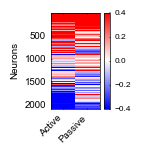

TypeError: Plotter.plot_mi_heatmap_by_context() got an unexpected keyword argument 'neuron_order'

In [82]:
# Main heatmaps: Active vs Passive (true and running-only predicted)
_,_,_,sound_heatmap_order = plotter.plot_mi_heatmap_by_context(
    mi_context_dicts=[mi_true_active_sound_only, mi_true_passive_sound_only],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=-0.4,
    vmax=0.4,
    title=None,#"Sound-only modulation index: true active vs passive",
    colorbar_label=None,#"Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_predicted_delta_mi_sound_responsive_neurons_sound_only.pdf',
    figsize = (1.39 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
)

_ = plotter.plot_mi_heatmap_by_context(
    mi_context_dicts=[mi_pred_active_sound_only, mi_pred_passive_sound_only],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    sort_context_index=(0,1),
    vmin=-0.4,
    vmax=0.4,
    title=None,#"Sound-only modulation index: predicted active vs passive",
    colorbar_label=None,#"Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_predicted_delta_mi_sound_responsive_neurons_sound_only.pdf',
    figsize = (1.39 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
    neuron_order=sound_heatmap_order
)

_,_,_,opto_heatmap_order = plotter.plot_mi_heatmap_by_context(
    mi_context_dicts=[ctrl_mi_true_active, ctrl_mi_true_passive],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=opto_responsive_mask_dict,
    datasets=datasets_opto,
    sort_context_index=(0,1),
    vmin=-0.4,
    vmax=0.4,
    title=None,#"Control modulation index: true active vs passive",
    colorbar_label=None,#"Control Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_control_delta_mi_opto_responsive_neurons.pdf',
    figsize = (1.35 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
)

_ = plotter.plot_mi_heatmap_by_context(
    mi_context_dicts=[ctrl_mi_pred_active, ctrl_mi_pred_passive],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=opto_responsive_mask_dict,
    datasets=datasets_opto,
    sort_context_index=(0,1),
    vmin=-0.4,
    vmax=0.4,
    title=None,#"Control modulation index: predicted active vs passive",
    colorbar_label=None,#"Control Modulation Index",
    cmap = 'bwr',
    save_path= 'W:/Connie/results/Bassi2025/glm_results/modulation_index/heatmap_predicted_control_delta_mi_opto_responsive_neurons.pdf',
    figsize = (1.35 , 1.55),
    ytick_mode = "matlab",
    cbar_fraction=0.1,
    cbar_pad=0.08,
    neuron_order=opto_heatmap_order
)


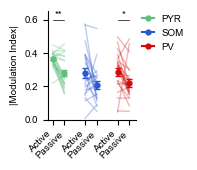

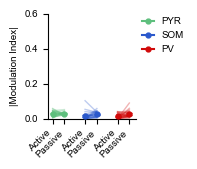

In [68]:
# Grouped cell-type summaries: sound-only MI, active vs passive
summary_true_sound_celltype = plotter.summarize_abs_mi_by_dataset(
    mi_context_dicts=[mi_true_active_sound_only, mi_true_passive_sound_only],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    cell_type_dict=cell_type_dict,
)

summary_pred_sound_celltype = plotter.summarize_abs_mi_by_dataset(
    mi_context_dicts=[mi_pred_active_sound_only, mi_pred_passive_sound_only],
    context_labels=["Active", "Passive"],
    neuron_mask_dict=sound_responsive_mask_dict,
    cell_type_dict=cell_type_dict,
)

stats_true_active_passive = plotter.compute_paired_context_stats(
    summary_df=summary_true_sound_celltype,
    metric_col="mean_abs_mi",
    context_a="Active",
    context_b="Passive",
    group_col="cell_type",
    n_permutations=1000,
)

stats_pred_active_passive = plotter.compute_paired_context_stats(
    summary_df=summary_pred_sound_celltype,
    metric_col="mean_abs_mi",
    context_a="Active",
    context_b="Passive",
    group_col="cell_type",
    n_permutations=1000,
)

_ = plotter.plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_true_sound_celltype,
    metric_col="mean_abs_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title=None,#"Sound-only modulation index: true active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_true_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=True,
    ylim=(0,.6),
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_true_sound_index_celltype_sound_only_trials.pdf',
    figsize=(2,1.7)
)

_ = plotter.plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_pred_sound_celltype,
    metric_col="mean_abs_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title=None,#"Sound-only modulation index: predicted active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_pred_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=True,
    ylim=(0,.6),
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_pred_sound_index_celltype_sound_only_trials.pdf',
    figsize=(2,1.7)
)


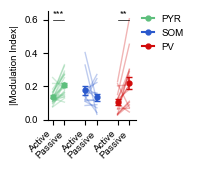

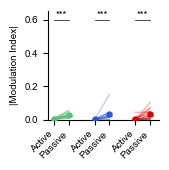

In [132]:
# Grouped cell-type summaries: control MI, active vs passive
summary_true_ctrl_celltype = plotter.summarize_abs_metric_by_dataset(
    metric_context_dicts=[ctrl_mi_true_active, ctrl_mi_true_passive],
    context_labels=["Active", "Passive"],
    metric_col="mean_abs_ctrl_mi",
    neuron_mask_dict=opto_responsive_mask_dict,
    cell_type_dict=cell_type_dict,
    metric_name="control modulation index",
    datasets = datasets_opto
)

summary_pred_ctrl_celltype = plotter.summarize_abs_metric_by_dataset(
    metric_context_dicts=[ctrl_mi_pred_active, ctrl_mi_pred_passive],
    context_labels=["Active", "Passive"],
    metric_col="mean_abs_ctrl_mi",
    neuron_mask_dict=opto_responsive_mask_dict,
    cell_type_dict=cell_type_dict,
    metric_name="control modulation index",
    datasets = datasets_opto
)

stats_true_ctrl_active_passive = plotter.compute_paired_context_stats(
    summary_df=summary_true_ctrl_celltype,
    metric_col="mean_abs_ctrl_mi",
    context_a="Active",
    context_b="Passive",
    group_col="cell_type",
    n_permutations=10000,
)

stats_pred_ctrl_active_passive = plotter.compute_paired_context_stats(
    summary_df=summary_pred_ctrl_celltype,
    metric_col="mean_abs_ctrl_mi",
    context_a="Active",
    context_b="Passive",
    group_col="cell_type",
    n_permutations=10000,
)

_ = plotter.plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_true_ctrl_celltype,
    metric_col="mean_abs_ctrl_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title= None,#"Control modulation index: true active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_true_ctrl_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=True,
    ylim=(0,.6),
    figsize=(2,1.7),
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_true_control_index_celltype_only_trials.pdf',

)

_ = plotter.plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_pred_ctrl_celltype,
    metric_col="mean_abs_ctrl_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title=None,#"Control modulation index: predicted active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_pred_ctrl_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=False,
    ylim=(0,.6),
    figsize=(1.7,1.7),
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_pred_control_index_celltype_only_trials.pdf',
)


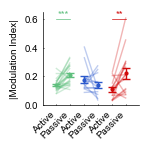

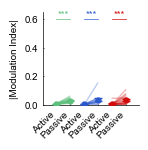

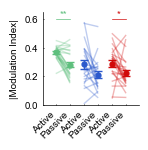

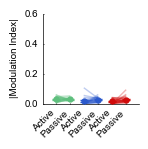

(<Figure size 150x150 with 1 Axes>, <Axes: ylabel='|Modulation Index|'>)

In [133]:
def plot_abs_metric_paired_summary_grouped_celltypes(
        summary_df,
        metric_col,
        context_order=None,
        cell_type_order=None,
        title=None,
        ylabel=None,
        ylim=None,
        save_path=None,
        show_stats=False,
        stats_df=None,
        alpha=0.05,
        use_bonferroni=False,
        star_height_percentage=0.01,
        group_gap=0.75,
        context_gap=1.0,
        show_celltype_labels=True,
        show_celltype_legend=False,
        line_alpha=0.3,
        line_width=1.0,
        mean_marker_size=3.5,
        figsize=None,
    ):
        """Paired dataset-line summary on one axis, grouped by cell type.

        Within each cell type, contexts are adjacent, e.g. Active/Passive or
        True/Predicted. Dataset lines connect only paired contexts within the
        same cell type.
        """
        plt.rcParams.update({"font.size": 7, "font.family": "arial"})
        mpl.rcParams["pdf.fonttype"] = 42

        df = summary_df.copy()
        required = {"dataset", "context", "cell_type", metric_col}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"summary_df is missing columns: {sorted(missing)}")

        if context_order is None:
            context_order = list(dict.fromkeys(df["context"].tolist()))
        if cell_type_order is None:
            cell_type_order = list(dict.fromkeys(df["cell_type"].tolist()))

        n_ctx = len(context_order)
        x_lookup = {}
        tick_x = []
        tick_labels = []

        for i, ct in enumerate(cell_type_order):
            start = i * (n_ctx * context_gap + group_gap)
            for j, ctx in enumerate(context_order):
                x = start + j * context_gap
                x_lookup[(ct, ctx)] = x
                tick_x.append(x)
                tick_labels.append(ctx)

        first_x = tick_x[0] if tick_x else 0.0
        last_x = tick_x[-1] if tick_x else 1.0

        if figsize is None:
            figsize = (max(2.6, 1.4 + 0.42 * (last_x - first_x + 1)), 2.6)

        fig, ax = plt.subplots(figsize=figsize)

        for ct in cell_type_order:
            sub = df.loc[df["cell_type"] == ct]
            color = plotter._cell_type_color(ct)
            xs = [x_lookup[(ct, ctx)] for ctx in context_order]

            # Individual dataset paired lines. No markers.
            for dataset, dset in sub.groupby("dataset", sort=False):
                ys = []
                for ctx in context_order:
                    match = dset.loc[dset["context"] == ctx, metric_col]
                    ys.append(float(match.iloc[0]) if len(match) else np.nan)

                ax.plot(
                    xs,
                    ys,
                    "-",
                    color=color,
                    alpha=line_alpha,
                    lw=line_width,
                )

            # Mean +/- SEM overlay.
            means = []
            sems = []
            for ctx in context_order:
                vals = sub.loc[sub["context"] == ctx, metric_col].to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                means.append(np.mean(vals) if vals.size else np.nan)
                sems.append(
                    np.std(vals, ddof=1) / np.sqrt(vals.size) if vals.size > 1 else np.nan
                )

            ax.errorbar(
                xs,
                means,
                yerr=sems,
                fmt="o",
                color=color,
                ms=mean_marker_size,
                lw=1,
                capsize=3,
                zorder=3,
            )

        ax.set_xticks(tick_x)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right")
        ax.set_xlim(first_x-1, last_x + 1)
        
        # MATLAB-style inward ticks
        ax.tick_params(
            axis="both",
            direction="in",
            top=False,
            right=False,
            length=1,
            width=0.5,
        )
        
        ax.set_ylabel(ylabel if ylabel is not None else metric_col)

        if title:
            ax.set_title(title, fontsize=7)

        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plotter._apply_paired_ylim(ax, ylim=ylim, y_floor=None)

        # Optional cell-type labels above groups.
        ymin, ymax = ax.get_ylim()
        y_span = ymax - ymin if np.isfinite(ymax - ymin) and (ymax - ymin) > 0 else 1.0

        label_y = ymax
        if show_celltype_labels:
            label_y = ymax + 0.04 * y_span
            for ct in cell_type_order:
                xs = [x_lookup[(ct, ctx)] for ctx in context_order]
                mid = 0.5 * (min(xs) + max(xs))
                ax.text(
                    mid,
                    label_y,
                    str(ct),
                    ha="center",
                    va="bottom",
                    color=plotter._cell_type_color(ct),
                    fontsize=7,
                    fontname="arial",
                )
            ax.set_ylim(ymin, label_y + 0.14 * y_span)

        # Optional legend instead of or in addition to top labels.
        if show_celltype_legend:

            handles = [
                Line2D(
                    [0],
                    [0],
                    color=plotter._cell_type_color(ct),
                    lw=1.5,
                    marker="o",
                    ms=3.5,
                    label=str(ct),
                )
                for ct in cell_type_order
            ]
            ax.legend(
                handles=handles,
                frameon=False,
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                fontsize=7,
                handlelength=1.2,
                borderaxespad=0,
            )

        # Optional stats annotation.
        if show_stats and stats_df is not None and len(stats_df):
            annotated = stats_df.copy()

            if "p_value" not in annotated.columns:
                raise ValueError("stats_df must include a 'p_value' column")

            if "_stars" not in annotated.columns:
                annotated = annotated.assign(
                    _stars=plotter._stars_from_p_values(
                        annotated["p_value"].tolist(),
                        use_bonferroni=use_bonferroni,
                        alpha=alpha,
                    )
                )

            ymin, ymax = ax.get_ylim()
            y_span = ymax - ymin if np.isfinite(ymax - ymin) and (ymax - ymin) > 0 else 1.0
            last_text_y = ymax
            any_star = False

            for ct in cell_type_order:
                if "group" in annotated.columns:
                    rows = annotated.loc[annotated["group"] == ct]
                elif "cell_type" in annotated.columns:
                    rows = annotated.loc[annotated["cell_type"] == ct]
                else:
                    continue

                local_stack = 0
                for _, row in rows.iterrows():
                    star = row["_stars"]
                    if star == "ns":
                        continue

                    ctx_a = row["context_a"]
                    ctx_b = row["context_b"]

                    if (ct, ctx_a) not in x_lookup or (ct, ctx_b) not in x_lookup:
                        continue

                    y = ymax + local_stack * 0.10 * y_span

                    plotter.add_significance_line(
                        ax,
                        x1=x_lookup[(ct, ctx_a)],
                        x2=x_lookup[(ct, ctx_b)],
                        y=y,
                        significance=star,
                        star_height_percentage=star_height_percentage,
                        color = plotter._cell_type_color(ct)
                    )

                    last_text_y = y + abs(y) * star_height_percentage
                    local_stack += 1
                    any_star = True

            if any_star:
                ax.set_ylim(ymin, max(ax.get_ylim()[1], last_text_y + 0.08 * y_span))

        fig.tight_layout()

        if save_path:
            plt.savefig(save_path, bbox_inches="tight", format="pdf")

        plt.show()
        return fig, ax

plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_true_ctrl_celltype,
    metric_col="mean_abs_ctrl_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title= None,#"Control modulation index: true active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_true_ctrl_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=False,
    ylim=(0,.6),
    figsize=(1.5,1.5),
    mean_marker_size=2,
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_true_control_index_celltype_only_trials.pdf',
    context_gap=1,
    group_gap=0.1,
)

plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_pred_ctrl_celltype,
    metric_col="mean_abs_ctrl_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title=None,#"Control modulation index: predicted active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_pred_ctrl_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=False,
    ylim=(0,.6),
    figsize=(1.5,1.5),
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_pred_control_index_celltype_only_trials.pdf',
    context_gap=1,
    group_gap=0.1,
)


plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_true_sound_celltype,
    metric_col="mean_abs_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title=None,#"Sound-only modulation index: true active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_true_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=False,
    ylim=(0,.6),
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_true_sound_index_celltype_sound_only_trials.pdf',
    figsize=(1.5,1.5),
    context_gap=1,
    group_gap=0.1,
)

plot_abs_metric_paired_summary_grouped_celltypes(
    summary_df=summary_pred_sound_celltype,
    metric_col="mean_abs_mi",
    context_order=["Active", "Passive"],
    cell_type_order=["PYR", "SOM", "PV"],
    title=None,#"Sound-only modulation index: predicted active vs passive",
    ylabel="|Modulation Index|",
    show_stats=True,
    stats_df=stats_pred_active_passive,
    show_celltype_labels=False,
    show_celltype_legend=False,
    ylim=(0,.6),
    save_path='W:/Connie/results/Bassi2025/glm_results/modulation_index/scatter_pred_sound_index_celltype_sound_only_trials.pdf',
    figsize=(1.5,1.5),
    context_gap=1,
    group_gap=0.1,
)

Plot true vs predictions  (aligned and not)

C:\Code/Github/GLM-analysis\utils\Plotter.py:5409: RuntimeWarning: Mean of empty slice
  velocity_fold_means.append(np.nanmean(velocity_data, axis=0))  # 2 x frames


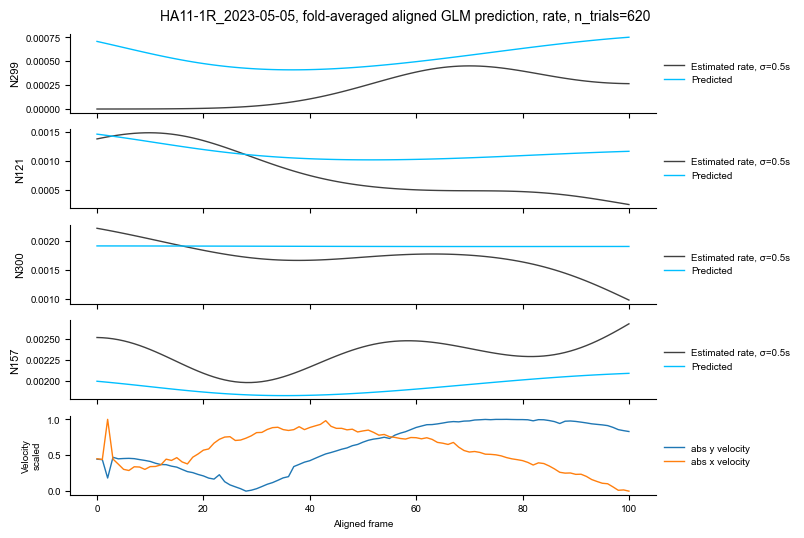

(<Figure size 800x540 with 5 Axes>,
 array([<Axes: ylabel='N299'>, <Axes: ylabel='N121'>,
        <Axes: ylabel='N300'>, <Axes: ylabel='N157'>,
        <Axes: xlabel='Aligned frame', ylabel='Velocity\nscaled'>],
       dtype=object),
 None,
 {'avg_true': array([[0.00097769, 0.        , 0.00052581, ..., 0.00114478, 0.00475861,
          0.00441078],
         [0.001539  , 0.00121551, 0.00026109, ..., 0.0002707 , 0.00059753,
          0.00055625],
         [0.        , 0.0002814 , 0.00189689, ..., 0.00118382, 0.00086485,
          0.00173568],
         ...,
         [0.01957462, 0.02077891, 0.02178733, ..., 0.00220078, 0.00032176,
          0.00026297],
         [0.00014329, 0.00273272, 0.00020289, ..., 0.00126899, 0.        ,
          0.00066064],
         [0.00309796, 0.0076532 , 0.00414672, ..., 0.0008138 , 0.00044337,
          0.00101407]]),
  'avg_pred': array([[0.00388332, 0.00392953, 0.0039733 , ..., 0.00515782, 0.00514736,
          0.00513691],
         [0.00291674, 0.00292795,

In [80]:
#Plot aligned data

key = "HA11-1R_2023-05-05"

top_neurons, negative_neurons = predictorfun.get_top_and_bottom_neurons(
    mean_frac_dev_by_key[key],
    n_examples=4
)

# selected_neurons = predictorfun.wrap_selected_neurons_for_plotting(
#     datasets=datasets,
#     neuron_ids=top_neurons,
# )
supp_figure_dir = None
plotter.plot_aligned_fold_average_neurons(
    key=key,
    aligned_true=aligned_neural_true,
    aligned_pred=aligned_neural_pred,
    aligned_velocity=aligned_velocity,
    neuron_ids=top_neurons, #sound_separated['sig_cells_neg'][0,1],
    folds=range(10),
    response_mode="rate",
    velocity_axis_order=("y", "x"),
    save_dir=supp_figure_dir,
    save_name=f"{key}_negative_neurons_aligned_rate.pdf",
)

C:\Code/Github/GLM-analysis\utils\Plotter.py:5409: RuntimeWarning: Mean of empty slice
  velocity_fold_means.append(np.nanmean(velocity_data, axis=0))  # 2 x frames


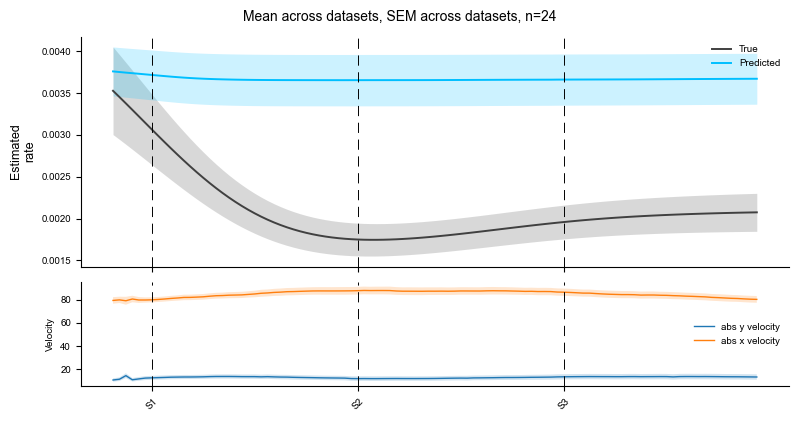

In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt
def plot_aligned_population_average(
    aligned_true,
    aligned_pred,
    aligned_velocity,
    datasets,
    neuron_ids=None,
    folds=range(10),
    average_mode="neurons",
    response_mode="deconvolved",
    imaging_rate_hz=30.4791,
    smooth_sigma_sec=0.5,
    velocity_axis_order=("y", "x"),
    frame_axis=None,
    title=None,
    save_dir=None,
    save_name=None,
    prediction_color="deepskyblue",
    event_frames=None,
    event_labels=None,
    velocity_plot_mode="both"
):
    """
    Plot aligned true vs predicted traces averaged either across neurons or datasets.

    average_mode:
        "neurons"  = one dataset, average selected neurons, SEM across neurons
        "datasets" = multiple datasets, average each dataset first, SEM across datasets

    response_mode:
        "deconvolved" = plot mean deconvolved activity
        "rate" = smooth true activity for estimated event-rate display
    velocity_plot_mode: 
        "both"      # plot y and x
        "y"         # plot only y
        "x"         # plot only x
        "magnitude" # plot sqrt(x^2 + y^2)
    """


    if average_mode not in ["neurons", "datasets"]:
        raise ValueError("average_mode must be 'neurons' or 'datasets'")

    true_units = []
    pred_units = []
    velocity_units = []

    for dataset_idx, (animalID, date, server) in enumerate(datasets):
        key = f'{animalID}_{date}'
        avg_true, avg_pred, avg_velocity, fold_counts = plotter.average_aligned_across_folds(
            aligned_true=aligned_true,
            aligned_pred=aligned_pred,
            aligned_velocity=aligned_velocity,
            key=key,
            folds=folds,
            velocity_axis_order=velocity_axis_order,
        )

        # avg_true/avg_pred are neurons x frames
        # avg_velocity is 2 x frames

        if response_mode == "rate":
            avg_true = plotter.smooth_neural_trace_for_display(
                avg_true,
                imaging_rate_hz=imaging_rate_hz,
                smooth_sigma_sec=smooth_sigma_sec,
                axis=-1,
            )

            # I would leave prediction unsmoothed because GLM prediction is already rate-like.
            avg_pred = avg_pred

        elif response_mode != "deconvolved":
            raise ValueError("response_mode must be 'deconvolved' or 'rate'")

        if neuron_ids is None:
            use_neurons = np.arange(avg_true.shape[0])
        else:
            use_neurons =  np.asarray(neuron_ids[0, dataset_idx]).squeeze()  #np.asarray(neuron_ids)

        if average_mode == "neurons":
            if len(datasets) != 1:
                raise ValueError("average_mode='neurons' expects one key/dataset at a time.")

            true_units = avg_true[use_neurons, :]       # neurons x frames
            pred_units = avg_pred[use_neurons, :]       # neurons x frames
            velocity_units = avg_velocity[None, :, :]   # 1 x 2 x frames

        elif average_mode == "datasets":
            true_units.append(np.nanmean(avg_true[use_neurons, :], axis=0))  # frames
            pred_units.append(np.nanmean(avg_pred[use_neurons, :], axis=0))  # frames
            velocity_units.append(avg_velocity)                              # 2 x frames

    if average_mode == "datasets":
        true_units = np.stack(true_units, axis=0)          # datasets x frames
        pred_units = np.stack(pred_units, axis=0)          # datasets x frames
        velocity_units = np.stack(velocity_units, axis=0)  # datasets x 2 x frames

    true_mean = np.nanmean(true_units, axis=0)
    pred_mean = np.nanmean(pred_units, axis=0)

    true_sem = np.nanstd(true_units, axis=0) / np.sqrt(true_units.shape[0])
    pred_sem = np.nanstd(pred_units, axis=0) / np.sqrt(pred_units.shape[0])

    n_frames = true_mean.shape[0]

    if frame_axis is None:
        frame_axis = np.arange(n_frames)
    else:
        frame_axis = np.asarray(frame_axis)
        if len(frame_axis) != n_frames:
            raise ValueError(
                f"frame_axis length {len(frame_axis)} does not match n_frames {n_frames}"
            )

    fig, axs = plt.subplots(
        2,
        1,
        figsize=(8, 4.2),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.0]},
    )

    ax = axs[0]

    ax.plot(
        frame_axis,
        true_mean,
        color=[0.25, 0.25, 0.25],
        linewidth=1.4,
        label="True",
    )

    ax.fill_between(
        frame_axis,
        true_mean - true_sem,
        true_mean + true_sem,
        color=[0.25, 0.25, 0.25],
        alpha=0.2,
        linewidth=0,
    )

    ax.plot(
        frame_axis,
        pred_mean,
        color=prediction_color,
        linewidth=1.4,
        label="Predicted",
    )

    ax.fill_between(
        frame_axis,
        pred_mean - pred_sem,
        pred_mean + pred_sem,
        color=prediction_color,
        alpha=0.2,
        linewidth=0,
    )

    if response_mode == "rate":
        ax.set_ylabel("Estimated\nrate", fontsize=9)
    else:
        ax.set_ylabel("Deconvolved\nactivity", fontsize=9)

    ax.legend(frameon=False, fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if event_frames is not None:         
        xlim = axs[0].get_xlim()
        for frame in event_frames:
            if frame < xlim[1]:
                axs[0].axvline(x=frame, color='k', linestyle=(0, (10.5,6.8)), alpha=1,lw=0.7)
        axs[0].set_xticks(event_frames)
        axs[0].set_xticklabels(event_labels, rotation=45, fontsize=7)

    ax = axs[1]

    vel0_label, vel1_label = velocity_axis_order

    # -----------------------------
    # Velocity mean and SEM, unscaled
    # -----------------------------
    # velocity_units shape:
    #   average_mode="datasets": datasets x 2 x frames
    #   average_mode="neurons":  1 x 2 x frames
    #
    # velocity_axis_order tells us what row 0 and row 1 mean.
    # Example:
    #   velocity_axis_order=("y", "x")
    #   velocity_units[:, 0, :] = y velocity
    #   velocity_units[:, 1, :] = x velocity

    if velocity_units.ndim != 3 or velocity_units.shape[1] != 2:
        raise ValueError(
            f"Expected velocity_units to be units x 2 x frames, got {velocity_units.shape}"
        )

    velocity_traces_to_plot = {}

    if velocity_plot_mode == "both":
        velocity_units_abs = np.abs(velocity_units)

        velocity_traces_to_plot[f"abs {vel0_label} velocity"] = velocity_units_abs[:, 0, :]
        velocity_traces_to_plot[f"abs {vel1_label} velocity"] = velocity_units_abs[:, 1, :]

    elif velocity_plot_mode == "y":
        if vel0_label == "y":
            y_idx = 0
        elif vel1_label == "y":
            y_idx = 1
        else:
            raise ValueError("velocity_axis_order must contain 'y' for velocity_plot_mode='y'")

        velocity_traces_to_plot["abs y velocity"] = np.abs(velocity_units[:, y_idx, :])

    elif velocity_plot_mode == "x":
        if vel0_label == "x":
            x_idx = 0
        elif vel1_label == "x":
            x_idx = 1
        else:
            raise ValueError("velocity_axis_order must contain 'x' for velocity_plot_mode='x'")

        velocity_traces_to_plot["abs x velocity"] = np.abs(velocity_units[:, x_idx, :])

    elif velocity_plot_mode == "magnitude":
        if vel0_label == "y":
            y_idx = 0
        elif vel1_label == "y":
            y_idx = 1
        else:
            raise ValueError("velocity_axis_order must contain 'y' for velocity_plot_mode='magnitude'")

        if vel0_label == "x":
            x_idx = 0
        elif vel1_label == "x":
            x_idx = 1
        else:
            raise ValueError("velocity_axis_order must contain 'x' for velocity_plot_mode='magnitude'")

        y_vel = velocity_units[:, y_idx, :]
        x_vel = velocity_units[:, x_idx, :]

        velocity_traces_to_plot["velocity magnitude"] = np.sqrt((x_vel ** 2) + (y_vel ** 2))

    velocity_mean = {}
    velocity_sem = {}

    for trace_label, trace_units in velocity_traces_to_plot.items():
        velocity_mean[trace_label] = np.nanmean(trace_units, axis=0)

        if trace_units.shape[0] > 1:
            velocity_sem[trace_label] = np.nanstd(trace_units, axis=0) / np.sqrt(trace_units.shape[0])
        else:
            velocity_sem[trace_label] = np.zeros_like(velocity_mean[trace_label])

    # Plot selected velocity traces
    for trace_label in velocity_traces_to_plot.keys():
        trace_mean = velocity_mean[trace_label]
        trace_sem = velocity_sem[trace_label]

        ax.plot(
            frame_axis,
            trace_mean,
            linewidth=1.0,
            label=trace_label
        )

        ax.fill_between(
            frame_axis,
            trace_mean - trace_sem,
            trace_mean + trace_sem,
            alpha=0.2,
            linewidth=0,
        )

    if event_frames is not None:         
        xlim = axs[1].get_xlim()
        for frame in event_frames:
            if frame < xlim[1]:
                axs[1].axvline(x=frame, color='k', linestyle=(0, (10.5,6.8)), alpha=1,lw=0.7)

        axs[1].set_xticks(event_frames)
        axs[1].set_xticklabels(event_labels, rotation=45, fontsize=7)

    ax.set_ylabel("Velocity", fontsize=7)
    # ax.set_xlabel("Aligned frame")
    ax.legend(frameon=False, fontsize=7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if title is None:
        if average_mode == "neurons":
            title = f"{datasets[0]}, mean across neurons, SEM across neurons"
        else:
            title = f"Mean across datasets, SEM across datasets, n={len(datasets)}"

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()

    saved_path = None

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        if save_name is None:
            if average_mode == "neurons":
                save_name = f"{datasets[0]}_aligned_mean_across_neurons_{response_mode}.pdf"
            else:
                save_name = f"aligned_mean_across_datasets_{response_mode}.pdf"

        saved_path = os.path.join(save_dir, save_name)
        plt.savefig(saved_path, bbox_inches="tight")
        print("Saved:", saved_path)

    plt.show()

    return fig, axs, saved_path, {
        "true_units": true_units,
        "pred_units": pred_units,
        "velocity_units": velocity_units,
        "true_mean": true_mean,
        "pred_mean": pred_mean,
        "true_sem": true_sem,
        "pred_sem": pred_sem,
        "velocity_mean": velocity_mean,
        "velocity_sem": velocity_sem,
        "velocity_plot_mode": velocity_plot_mode,
            }

fig, axs, saved_path, out = plot_aligned_population_average(
    aligned_true=aligned_neural_true,
    aligned_pred=aligned_neural_pred,
    aligned_velocity=aligned_velocity,
    datasets=datasets,
    neuron_ids=sound_separated['sig_cells_neg'],
    folds=range(10),
    average_mode="datasets",
    response_mode="rate", #"rate" or deconvolved
    velocity_axis_order=("y", "x"),
    save_dir=None,
    event_frames= plotter.event_frames[:3],  # Use the first three event frames
    event_labels= plotter.event_labels[:3],
    velocity_plot_mode="both" #x,y,both, magnitude
)

In [142]:
#LOAD RUNNING PREDICTORS AND RESPONSE FOR EXAMPLE DATASET
### settings
example_dataset = mouse_dates_keys[0]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')
fold_number = 0
model_type = 'GLM_running'
running_trace_mode = "raw_velocity_no_processing" #"raw_velocity_split" #"raw_velocity" or "grouped_predictors"
current_context = "active"  # or "passive"
##load data
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
if current_context == "active":
    path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")
else:
    path = os.path.join(save_directory, f"{current_context}_{fold_number + 1}/test")

response_matrix = predictorfun.load_test_response(path)

def load_running_predictors(path, expected_n_predictors=32):
        """
        Load behav_big_matrix.mat.

        Expected output:
            running_predictors: predictors x frames

        If saved as frames x predictors, transpose automatically.
        """
        predictor_path = os.path.join(path, "behav_big_matrix.mat")

        if not os.path.exists(predictor_path):
            raise FileNotFoundError(f"Could not find behav_big_matrix.mat at: {predictor_path}")

        pred_file = scipy.io.loadmat(predictor_path)

        if "behav_big_matrix" not in pred_file:
            raise KeyError(
                f"'behav_big_matrix' not found in behav_big_matrix.mat. "
                f"Available keys: {list(pred_file.keys())}"
            )

        running_predictors = np.asarray(pred_file["behav_big_matrix"])

        if running_predictors.ndim != 2:
            raise ValueError(
                f"Expected behav_big_matrix to be 2D, got shape {running_predictors.shape}"
            )

        # If saved as frames x predictors, transpose it.
        if (
            running_predictors.shape[0] != expected_n_predictors
            and running_predictors.shape[1] == expected_n_predictors
        ):
            running_predictors = running_predictors.T

        if running_predictors.shape[0] != expected_n_predictors:
            raise ValueError(
                f"Expected running_predictors to be "
                f"{expected_n_predictors} x frames, got {running_predictors.shape}"
            )

        return running_predictors

# running_predictors = predictorfun.load_running_predictors(path, expected_n_predictors=2)
running_predictors = load_running_predictors(path)

model_output = results_pre[example_dataset][f"model_output_running_{current_context}"]

fold_output = model_output[fold_number]
y_pred = fold_output["y_pred"]
frac_dev_expl = fold_output["frac_dev_expl"]

predictorfun.validate_response_prediction_shapes(response_matrix, y_pred)

running_group_summaries = predictorfun.summarize_running_predictors_for_display(
    running_predictors,
    group_mode="4_groups"
)

velocity = predictorfun.load_velocity(path)
velocity_dict = predictorfun.split_velocity(velocity)
velocity_display_traces = predictorfun.make_raw_velocity_display_traces(
    velocity_dict,
    mode=running_trace_mode
)

top_positive_neurons, negative_neurons = predictorfun.get_top_and_bottom_neurons(
    frac_dev_expl,
    n_examples=4
)

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

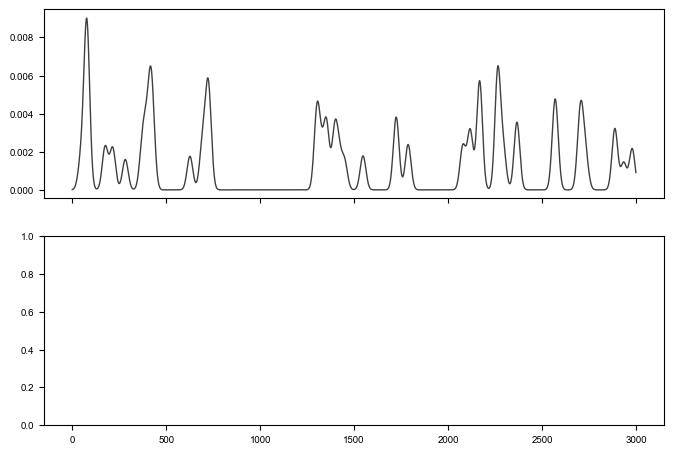

In [143]:
#PLOT EXAMPLE TRACES FOR TOP AND BOTTOM NEURONS
supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)
plot_windows = [(0,3000)]
running_trace_mode = "raw_velocity" #"raw_velocity_split" #"raw_velocity" or "grouped_predictors"
frac_dev_expl = mean_frac_dev_by_key_all
top_positive_neurons, negative_neurons = predictorfun.get_top_and_bottom_neurons(
    frac_dev_expl,
    n_examples=4
)

for frame_start, frame_end in plot_windows:
    plotter.plot_running_glm_neuron_group(
        neuron_ids=top_positive_neurons,
        frame_start=frame_start,
        frame_end=frame_end,
        response_matrix=response_matrix,
        y_pred=y_pred,
        frac_dev_expl=frac_dev_expl,
        running_trace_mode=running_trace_mode,
        running_group_summaries=running_group_summaries,
        velocity_display_traces=velocity_display_traces,
        supp_figure_dir=supp_figure_dir,
        animalID=animalID,
        date=date,
        model_type=model_type,
        fold_number=fold_number,
        label="top_positive_running_fracdev",
        plot_real_activity = False,
        save_string = current_context
    )

    plotter.plot_running_glm_neuron_group(
        neuron_ids=negative_neurons,
        frame_start=frame_start,
        frame_end=frame_end,
        response_matrix=response_matrix,
        y_pred=y_pred,
        frac_dev_expl=frac_dev_expl,
        running_trace_mode=running_trace_mode,
        running_group_summaries=running_group_summaries,
        velocity_display_traces=velocity_display_traces,
        supp_figure_dir=supp_figure_dir,
        animalID=animalID,
        date=date,
        model_type=model_type,
        fold_number=fold_number,
        label="most_negative_running_fracdev",
        plot_real_activity = False,
        save_string = current_context
    )

plotter.plot_single_neuron_predictor_heatmap(
    neuron_idx=top_positive_neurons[0],
    frame_start=0,
    frame_end=5000,
    response_matrix=response_matrix,
    y_pred=y_pred,
    frac_dev_expl=frac_dev_expl,
    running_predictors=running_predictors,
    supp_figure_dir=supp_figure_dir,
    animalID=animalID,
    date=date,
    model_type=model_type,
    fold_number=fold_number,
    label="top_positive_running_fracdev",
)

In [144]:
#settings
example_dataset = mouse_dates_keys[0]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")
# -----------------------------
# Load neural response
# -----------------------------

response_path = os.path.join(path, 'combined_response.mat')
response = scipy.io.loadmat(response_path)
response_matrix = np.asarray(response['combined_response'])  # neurons x frames

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

y_pred = np.asarray(fold_output['y_pred'])  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

# -----------------------------
# Load convolved running predictors
# -----------------------------

predictor_path = os.path.join(path, 'behav_big_matrix.mat')
pred_file = scipy.io.loadmat(predictor_path)

# path = predictorfun.get_fold_test_path(server, animalID, date, "GLM_running", fold_number)

# response_matrix = predictorfun.load_test_response(path)
# running_predictors = predictorfun.load_running_predictors(path)

model_output = results_pre[example_dataset]["model_output_running_active"]
fold_output = model_output[fold_number]
y_pred = fold_output["y_pred"]
frac_dev_expl = fold_output["frac_dev_expl"]

running_trace_mode = "raw_velocity_split"

# Choose whether to also make single-neuron heatmaps of all 32 convolved predictors
make_heatmaps = True

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# Use 4 grouped convolved traces or 8 grouped convolved traces
# Only affects running_trace_mode = "grouped_predictors"
predictor_group_mode = "4_groups"


# -----------------------------
# Load raw velocity ONLY if needed
# -----------------------------

running_predictors = np.asarray(pred_file['behav_big_matrix'])  # expected 32 x frames

# If saved as frames x predictors, transpose it
if running_predictors.shape[0] != 32 and running_predictors.shape[1] == 32:
    running_predictors = running_predictors.T

if running_predictors.shape[0] != 32:
    raise ValueError(
        f"Expected running_predictors to be 32 x frames, got {running_predictors.shape}"
    )

velocity = None
x_velocity_raw = None
y_velocity_raw = None
pos_x_velocity_raw = None
neg_x_velocity_raw = None
pos_y_velocity_raw = None
neg_y_velocity_raw = None

if running_trace_mode in ["raw_velocity", "raw_velocity_split"]:
    velocity_path = os.path.join(path, 'velocity.mat')

    if not os.path.exists(velocity_path):
        raise FileNotFoundError(f"Could not find velocity.mat at: {velocity_path}")

    velocity_file = scipy.io.loadmat(velocity_path)

    if 'velocity' not in velocity_file:
        raise KeyError(
            f"'velocity' not found in velocity.mat. "
            f"Available keys: {list(velocity_file.keys())}"
        )

    velocity = np.asarray(velocity_file['velocity']).squeeze()

    # Ensure velocity is 2 x frames
    if velocity.ndim != 2:
        raise ValueError(f"Expected velocity to be 2D, got shape {velocity.shape}")

    if velocity.shape[0] != 2 and velocity.shape[1] == 2:
        velocity = velocity.T

    if velocity.shape[0] != 2:
        raise ValueError(f"Expected velocity to be 2 x frames, got {velocity.shape}")

    x_velocity_raw = velocity[0, :]
    y_velocity_raw = velocity[1, :]

    pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
    neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

    pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
    neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

    x_overlap = np.sum((pos_x_velocity_raw > 0) & (neg_x_velocity_raw > 0))
    y_overlap = np.sum((pos_y_velocity_raw > 0) & (neg_y_velocity_raw > 0))

    print("velocity shape, x/y x frames:", velocity.shape)
    print(f"Raw +x and -x overlap frames: {x_overlap}")
    print(f"Raw +y and -y overlap frames: {y_overlap}")

# predictorfun.validate_response_prediction_shapes(response_matrix, y_pred)

running_group_summaries = predictorfun.summarize_running_predictors_for_display(
    running_predictors,
    group_mode="4_groups"
)

velocity = predictorfun.load_velocity(path)
velocity_dict = predictorfun.split_velocity(velocity)
velocity_display_traces = predictorfun.make_raw_velocity_display_traces(
    velocity_dict,
    mode="raw_velocity_split"
)

top_neurons, negative_neurons = predictorfun.get_top_and_bottom_neurons(
    frac_dev_expl,
    n_examples=4
)

velocity shape, x/y x frames: (2, 22956)
Raw +x and -x overlap frames: 0
Raw +y and -y overlap frames: 0


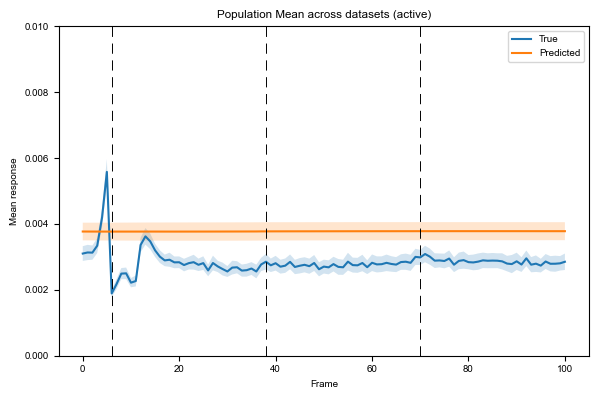

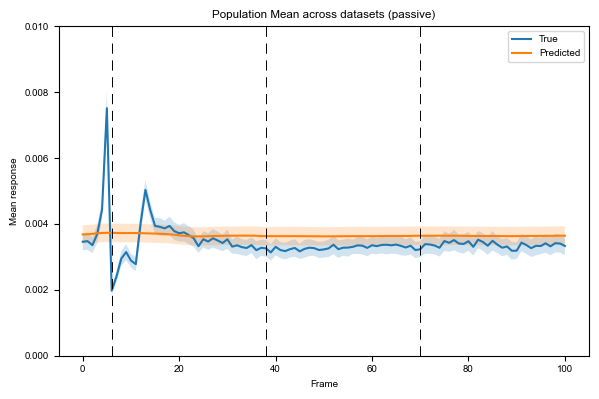

{'true_by_dataset': array([[0.00288169, 0.00292815, 0.00266497, ..., 0.00214699, 0.00257486,
         0.00212488],
        [0.00193534, 0.00177944, 0.00236247, ..., 0.00151123, 0.00153043,
         0.00160284],
        [0.00250487, 0.00262639, 0.00269201, ..., 0.00247712, 0.00257429,
         0.00256273],
        ...,
        [0.00305155, 0.00349754, 0.00326348, ..., 0.00438198, 0.00405209,
         0.00406525],
        [0.00171359, 0.00203502, 0.00198295, ..., 0.00212721, 0.00242377,
         0.00244248],
        [0.00218849, 0.00229174, 0.00193888, ..., 0.00237275, 0.00207438,
         0.00230653]]),
 'pred_by_dataset': array([[0.00251574, 0.00251024, 0.00250619, ..., 0.00247325, 0.00247287,
         0.00247321],
        [0.00209834, 0.0021003 , 0.00210581, ..., 0.00207301, 0.00207473,
         0.00207619],
        [0.00267187, 0.00272346, 0.0027879 , ..., 0.00263836, 0.00263602,
         0.0026333 ],
        ...,
        [0.00418704, 0.00420675, 0.00423144, ..., 0.0041649 , 0.004167

In [145]:
import numpy as np
import matplotlib.pyplot as plt


def mean_response_per_key(aligned_neural):
    """
    aligned_neural[key][fold] has shape:
        trials x neurons x frames

    Returns:
        key_means[key] with shape:
            neurons x frames
    """

    key_means = {}

    for key, folds in aligned_neural.items():

        fold_means = []

        # works whether folds is a list or dict
        fold_iter = folds.values() if isinstance(folds, dict) else folds

        for fold_data in fold_iter:
            # mean over trials
            # trials x neurons x frames -> neurons x frames
            fold_mean = np.nanmean(fold_data, axis=0)
            fold_means.append(fold_mean)

        # mean over folds
        # folds x neurons x frames -> neurons x frames
        key_means[key] = np.nanmean(np.stack(fold_means, axis=0), axis=0)

    return key_means

def plot_neuron_for_key(true_means, pred_means, key, neuron_idx, frame_times=None):
    """
    Plots true vs predicted mean response for one neuron from one key.
    """

    true_resp = true_means[key][neuron_idx, :]
    pred_resp = pred_means[key][neuron_idx, :]

    if frame_times is None:
        x = np.arange(true_resp.shape[0])
        xlabel = "Frame"
    else:
        x = frame_times
        xlabel = "Time"

    plt.figure(figsize=(6, 4))
    plt.plot(x, true_resp, label="True")
    plt.plot(x, pred_resp, label="Predicted")

    plt.xlabel(xlabel)
    plt.ylabel("Mean response")
    plt.title(f"{key} | neuron {neuron_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt


def plot_population_mean_across_keys(
    true_means,
    pred_means,
    keys=None,
    frame_times=None,
    error="sem",
    cell_indices_by_dataset=None,
    cell_index_col=0,
    dataset_axis_matches_keys=True,
    title="Population mean across datasets",
    event_onset = [6, 38, 70],
    ylims = (0,0.007)
):
    """
    Plots true vs predicted mean response across datasets.

    Parameters
    ----------
    true_means : dict
        true_means[key] has shape neurons x frames

    pred_means : dict
        pred_means[key] has shape neurons x frames

    keys : list, optional
        Dataset keys to include. If None, uses all keys in true_means.

    frame_times : array-like, optional
        Time values for x-axis. If None, uses frame number.

    error : {"sem", "std", None}
        Error band across datasets.

    cell_indices_by_dataset : array-like, optional
        Object where cell_indices_by_dataset[dataset_idx, cell_index_col]
        gives neuron indices to use for that dataset.

        Example:
            sig_cells[dataset_idx, 0]

        If None, all neurons are used.

    cell_index_col : int
        Column of cell_indices_by_dataset containing the cell indices.
        Default is 0.

    dataset_axis_matches_keys : bool
        If True, assumes dataset_idx is the position of the key in keys.
        So for keys[0], uses sig_cells[0, 0].
        For keys[1], uses sig_cells[1, 0], etc.

    title : str
        Plot title.
    """

    if keys is None:
        keys = list(true_means.keys())

    true_by_dataset = []
    pred_by_dataset = []
    used_keys = []
    n_cells_used = []

    for dataset_idx, key in enumerate(keys):

        true_data = true_means[key]  # neurons x frames
        pred_data = pred_means[key]  # neurons x frames

        if cell_indices_by_dataset is not None:
            if dataset_axis_matches_keys:
                cell_idx = cell_indices_by_dataset[cell_index_col, dataset_idx] -1  # convert from MATLAB 1-based to Python 0-based
            else:
                # useful if key itself is the dataset number
                cell_idx = cell_indices_by_dataset[key, cell_index_col] -1  # convert from MATLAB 1-based to Python 0-based

            cell_idx = np.asarray(cell_idx).astype(int)

            # skip dataset if no cells
            if len(cell_idx) == 0:
                continue

            true_data = true_data[cell_idx, :]
            pred_data = pred_data[cell_idx, :]

        # average over selected neurons
        # neurons x frames -> frames
        true_pop = np.nanmean(true_data, axis=0)
        pred_pop = np.nanmean(pred_data, axis=0)

        true_by_dataset.append(true_pop)
        pred_by_dataset.append(pred_pop)
        used_keys.append(key)
        n_cells_used.append(true_data.shape[0])

    # datasets x frames
    true_by_dataset = np.stack(true_by_dataset, axis=0)
    pred_by_dataset = np.stack(pred_by_dataset, axis=0)

    # mean across datasets
    true_mean = np.nanmean(true_by_dataset, axis=0)
    pred_mean = np.nanmean(pred_by_dataset, axis=0)

    if error == "sem":
        true_err = np.nanstd(true_by_dataset, axis=0, ddof=1) / np.sqrt(true_by_dataset.shape[0])
        pred_err = np.nanstd(pred_by_dataset, axis=0, ddof=1) / np.sqrt(pred_by_dataset.shape[0])
    elif error == "std":
        true_err = np.nanstd(true_by_dataset, axis=0, ddof=1)
        pred_err = np.nanstd(pred_by_dataset, axis=0, ddof=1)
    elif error is None:
        true_err = None
        pred_err = None
    else:
        raise ValueError("error must be 'sem', 'std', or None")

    if frame_times is None:
        x = np.arange(true_mean.shape[0])
        xlabel = "Frame"
    else:
        x = frame_times
        xlabel = "Time"

    plt.figure(figsize=(6, 4))

    plt.plot(x, true_mean, label="True")
    plt.plot(x, pred_mean, label="Predicted")
    

    if true_err is not None:
        plt.fill_between(
            x,
            true_mean - true_err,
            true_mean + true_err,
            alpha=0.2
        )
        plt.fill_between(
            x,
            pred_mean - pred_err,
            pred_mean + pred_err,
            alpha=0.2
        )

    
    ax = plt.gca()
    for event in event_onset:
        ax.axvline(x=event, color='k', linestyle=(0, (10.5,6.8)), alpha=1,lw=0.7)

    if ylims is not None:
        ax.set(ylim=(ylims))

    plt.xlabel(xlabel)
    plt.ylabel("Mean response")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "true_by_dataset": true_by_dataset,
        "pred_by_dataset": pred_by_dataset,
        "true_mean": true_mean,
        "pred_mean": pred_mean,
        "used_keys": used_keys,
        "n_cells_used": n_cells_used
    }

true_means = mean_response_per_key(aligned_neural_true)
pred_means = mean_response_per_key(aligned_neural_pred)

# plot_neuron_for_key(
#     true_means=true_means,
#     pred_means=pred_means,
#     key="HA11-1R_2023-05-05",
#     neuron_idx=10
# )

plot_population_mean_across_keys(
    true_means=true_means,
    pred_means=pred_means,
    error="sem",
    cell_indices_by_dataset=sound['sig_cells'],  # example of how to pass sig cells to only plot those
    cell_index_col=0,
    ylims = (0,0.01),
    title = 'Population Mean across datasets (active)'
)


true_means_passive = mean_response_per_key(aligned_neural_true_passive)
pred_means_passive = mean_response_per_key(aligned_neural_pred_passive)


plot_population_mean_across_keys(
    true_means=true_means_passive,
    pred_means=pred_means_passive,
    error="sem",
    cell_indices_by_dataset=sound['sig_cells'],  # example of how to pass sig cells to only plot those
    cell_index_col=0,
    ylims = (0,0.01),
    title = 'Population Mean across datasets (passive)'
)

Code below used for plotting example predicted traces

velocity shape, x/y x frames: (2, 11065)
Raw +x and -x overlap frames: 0
Raw +y and -y overlap frames: 0
Path: V:/Connie/ProcessedData/HA2-1L/2023-04-12/GLM_running/passive_1/test
running_trace_mode: raw_velocity_split
response_matrix shape, neurons x frames: (377, 11065)
y_pred shape, frames x neurons: (11065, 377)
running_predictors shape, predictors x frames: (32, 11065)
frac_dev_expl shape: (377,)
Smoothed rate sigma: 0.5 sec = 15.24 frames

Top positive running FDE neurons:
Neuron 158: FDE = 0.227
Neuron 270: FDE = 0.223
Neuron 192: FDE = 0.219

Most negative running FDE neurons:
Neuron 256: FDE = -0.062
Neuron 343: FDE = -0.053
Neuron 275: FDE = -0.046


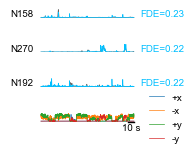

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_raw_velocity_split_HA2-1L_2023-04-12_GLM_running_fold1_0to4999_minimal.pdf


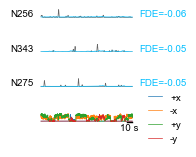

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_raw_velocity_split_HA2-1L_2023-04-12_GLM_running_fold1_0to4999_minimal.pdf


In [155]:
# Plot running-only GLM predictions, true deconvolved activity, smoothed event rate,
# and either convolved running predictors or raw velocity traces.
#
# Assumptions:
# - combined_response.mat contains "combined_response" with shape neurons x frames
# - behav_big_matrix.mat contains "behav_big_matrix" with shape 32 predictors x frames
# - velocity.mat contains "velocity" with shape 2 x frames:
#       velocity[0, :] = x velocity
#       velocity[1, :] = y velocity
# - y_pred has shape frames x neurons
# - frac_dev_expl has shape neurons

import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Settings
# -----------------------------

example_dataset = mouse_dates_keys[2]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"passive_{fold_number + 1}/test")

supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)

n_examples = 3
plot_windows = [(0, 5000)]  # examples: [(0,1000), (1000,2000), (2000,3000)]

# Choose what the BOTTOM PANEL shows:
# "grouped_predictors" = convolved +y, -y, +x, -x predictor summaries
# "raw_velocity" = raw abs(x), abs(y)
# "raw_velocity_split" = raw +x, -x, +y, -y
# running_trace_mode = "grouped_predictors"
# running_trace_mode = "raw_velocity"
running_trace_mode = "raw_velocity_split"

# Choose whether to also make single-neuron heatmaps of all 32 convolved predictors
make_heatmaps = False

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# Use 4 grouped convolved traces or 8 grouped convolved traces
# Only affects running_trace_mode = "grouped_predictors"
predictor_group_mode = "4_groups"
# predictor_group_mode = "8_groups"

# -----------------------------
# Helper functions
# -----------------------------

def zscore_for_display(x, axis=1, eps=1e-12):
    """
    Display-only z-score.
    For predictors x frames, use axis=1 to z-score each predictor over time.
    """
    x = np.asarray(x).astype(float).copy()
    mu = np.nanmean(x, axis=axis, keepdims=True)
    sigma = np.nanstd(x, axis=axis, keepdims=True)
    sigma[sigma < eps] = 1.0
    return (x - mu) / sigma


def minmax_for_display(x, eps=1e-12):
    """
    Display-only min-max scaling to 0-1.
    """
    x = np.asarray(x).astype(float).copy()
    x = x - np.nanmin(x)

    denom = np.nanmax(x)
    if denom < eps:
        denom = 1.0

    return x / denom


def make_plot_frames(frame_start, frame_end, max_frame):
    frames = np.arange(frame_start, min(frame_end, max_frame))

    if len(frames) == 0:
        raise ValueError(
            f"No frames to plot. frame_start={frame_start}, "
            f"frame_end={frame_end}, max_frame={max_frame}"
        )

    return frames


# -----------------------------
# Load neural response
# -----------------------------

response_path = os.path.join(path, 'combined_response.mat')
response = scipy.io.loadmat(response_path)
response_matrix = np.asarray(response['combined_response'])  # neurons x frames

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_passive']
fold_output = model_output[fold_number]

y_pred = np.asarray(fold_output['y_pred'])  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

# -----------------------------
# Load convolved running predictors
# -----------------------------

predictor_path = os.path.join(path, 'behav_big_matrix.mat')
pred_file = scipy.io.loadmat(predictor_path)

if 'behav_big_matrix' not in pred_file:
    raise KeyError(
        f"'behav_big_matrix' not found in behav_big_matrix.mat. "
        f"Available keys: {list(pred_file.keys())}"
    )

running_predictors = np.asarray(pred_file['behav_big_matrix'])  # expected 32 x frames

# If saved as frames x predictors, transpose it
if running_predictors.shape[0] != 32 and running_predictors.shape[1] == 32:
    running_predictors = running_predictors.T

if running_predictors.shape[0] != 32:
    raise ValueError(
        f"Expected running_predictors to be 32 x frames, got {running_predictors.shape}"
    )

# -----------------------------
# Load raw velocity ONLY if needed
# -----------------------------

velocity = None
x_velocity_raw = None
y_velocity_raw = None
pos_x_velocity_raw = None
neg_x_velocity_raw = None
pos_y_velocity_raw = None
neg_y_velocity_raw = None

if running_trace_mode in ["raw_velocity", "raw_velocity_split"]:
    velocity_path = os.path.join(path, 'velocity.mat')

    if not os.path.exists(velocity_path):
        raise FileNotFoundError(f"Could not find velocity.mat at: {velocity_path}")

    velocity_file = scipy.io.loadmat(velocity_path)

    if 'velocity' not in velocity_file:
        raise KeyError(
            f"'velocity' not found in velocity.mat. "
            f"Available keys: {list(velocity_file.keys())}"
        )

    velocity = np.asarray(velocity_file['velocity']).squeeze()

    # Ensure velocity is 2 x frames
    if velocity.ndim != 2:
        raise ValueError(f"Expected velocity to be 2D, got shape {velocity.shape}")

    if velocity.shape[0] != 2 and velocity.shape[1] == 2:
        velocity = velocity.T

    if velocity.shape[0] != 2:
        raise ValueError(f"Expected velocity to be 2 x frames, got {velocity.shape}")

    x_velocity_raw = velocity[0, :]
    y_velocity_raw = velocity[1, :]

    pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
    neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

    pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
    neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

    x_overlap = np.sum((pos_x_velocity_raw > 0) & (neg_x_velocity_raw > 0))
    y_overlap = np.sum((pos_y_velocity_raw > 0) & (neg_y_velocity_raw > 0))

    print("velocity shape, x/y x frames:", velocity.shape)
    print(f"Raw +x and -x overlap frames: {x_overlap}")
    print(f"Raw +y and -y overlap frames: {y_overlap}")

# -----------------------------
# Print checks
# -----------------------------

print("Path:", path)
print("running_trace_mode:", running_trace_mode)
print("response_matrix shape, neurons x frames:", response_matrix.shape)
print("y_pred shape, frames x neurons:", y_pred.shape)
print("running_predictors shape, predictors x frames:", running_predictors.shape)
print("frac_dev_expl shape:", frac_dev_expl.shape)
print(f"Smoothed rate sigma: {smooth_sigma_sec} sec = {smooth_sigma_frames:.2f} frames")

assert response_matrix.shape[0] == y_pred.shape[1], (
    f"Neuron mismatch: response has {response_matrix.shape[0]} neurons, "
    f"y_pred has {y_pred.shape[1]} neurons"
)

if response_matrix.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: frame mismatch. response has {response_matrix.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

if running_predictors.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: predictor frame mismatch. running_predictors has {running_predictors.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

# -----------------------------
# Create grouped convolved predictor traces
# -----------------------------

running_pred_z = zscore_for_display(running_predictors, axis=1)

predictor_groups_4 = {
    '+y': np.arange(0, 8),
    '-y': np.arange(8, 16),
    '+x': np.arange(16, 24),
    '-x': np.arange(24, 32),
}

predictor_groups_8 = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}

if predictor_group_mode == "4_groups":
    predictor_groups_to_plot = predictor_groups_4
elif predictor_group_mode == "8_groups":
    predictor_groups_to_plot = predictor_groups_8
else:
    raise ValueError("predictor_group_mode must be '4_groups' or '8_groups'")

running_group_summaries = {}

for group_name, group_idx in predictor_groups_to_plot.items():
    group_trace = np.nanmean(np.abs(running_pred_z[group_idx, :]), axis=0)
    running_group_summaries[group_name] = minmax_for_display(group_trace)

# -----------------------------
# Select neurons
# -----------------------------

top_positive_neurons = np.argsort(frac_dev_expl)[::-1][:n_examples]
most_negative_neurons = np.argsort(frac_dev_expl)[:n_examples]

print("\nTop positive running FDE neurons:")
for n in top_positive_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

print("\nMost negative running FDE neurons:")
for n in most_negative_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

# -----------------------------
# Main plotting function
# -----------------------------

def plot_neuron_group(neuron_ids, frame_start, frame_end, label, figsize=(8, 1.35), plot_smoothed_rate=True, plot_velocity=True):
    """
    Multi-neuron plot.
    Bottom panel is controlled directly by running_trace_mode.
    """
    max_frame = min(
        response_matrix.shape[1],
        y_pred.shape[0],
        running_predictors.shape[1]
    )

    if running_trace_mode in ["raw_velocity", "raw_velocity_split"]:
        max_frame = min(max_frame, velocity.shape[1])

    frames = make_plot_frames(frame_start, frame_end, max_frame)

    if plot_velocity:
        n_rows = len(neuron_ids) + 1
    else:
        n_rows = len(neuron_ids)

    fig, axs = plt.subplots(
        n_rows,
        1,
        figsize=figsize,
        sharex=True
    )

    if n_rows == 1:
        axs = [axs]

    # -----------------------------
    # Neural panels
    # -----------------------------

    for i, neuron_idx in enumerate(neuron_ids):
        ax = axs[i]

        true_y = response_matrix[neuron_idx, frames]
        pred_y = y_pred[frames, neuron_idx]

        # ax.plot(
        #     frames,
        #     true_y,
        #     color=[0.75, 0.75, 0.75],
        #     linewidth=0.6,
        #     label='Deconvolved'
        # )

        if plot_smoothed_rate:
            true_rate = gaussian_filter1d(
                true_y.astype(float),
                sigma=smooth_sigma_frames,
                mode='nearest'
            )

            ax.plot(
                frames,
                true_rate,
                color=[0.25, 0.25, 0.25],
                linewidth=0.5,
                label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
            )

        ax.plot(
            frames,
            pred_y,
            color='deepskyblue',
            linewidth=0.5,
            label=f'FDE={frac_dev_expl[neuron_idx]:.2f}' #Running-only GLM, 
        )

        ax.set_ylabel(f'N{neuron_idx}', fontsize=7)
        ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # -----------------------------
    # Bottom running panel
    # THIS IS WHERE running_trace_mode IS USED
    # -----------------------------
    if plot_velocity:
        ax = axs[-1]

        if running_trace_mode == "grouped_predictors":
            for group_name, group_trace in running_group_summaries.items():
                ax.plot(
                    frames,
                    group_trace[frames],
                    linewidth=0.5,
                    label=group_name
                )

            ax.set_ylabel('Convolved\npred.', fontsize=7)

        elif running_trace_mode == "raw_velocity":
            abs_x = minmax_for_display(np.abs(x_velocity_raw))
            abs_y = minmax_for_display(np.abs(y_velocity_raw))

            ax.plot(frames, abs_x[frames], linewidth=0.5, label='abs x raw')
            ax.plot(frames, abs_y[frames], linewidth=0.5, label='abs y raw')

            ax.set_ylabel('Raw vel.', fontsize=7)

        elif running_trace_mode == "raw_velocity_split":
            px = minmax_for_display(pos_x_velocity_raw)
            nx = minmax_for_display(neg_x_velocity_raw)
            py = minmax_for_display(pos_y_velocity_raw)
            ny = minmax_for_display(neg_y_velocity_raw)

            ax.plot(frames, px[frames], linewidth=0.5, label='+x raw')
            ax.plot(frames, nx[frames], linewidth=0.5, label='-x raw')
            ax.plot(frames, py[frames], linewidth=0.5, label='+y raw')
            ax.plot(frames, ny[frames], linewidth=0.5, label='-y raw')

            ax.set_ylabel('Raw vel.\nsplit', fontsize=7)

        else:
            raise ValueError(
                "running_trace_mode must be one of: "
                "'grouped_predictors', 'raw_velocity', or 'raw_velocity_split'"
            )

    ax.set_xlabel('Frame', fontsize=7)
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # fig.suptitle(
    #     f'{animalID} {date}, fold {fold_number + 1}, {label}, mode={running_trace_mode}',
    #     fontsize=10
    # )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_{running_trace_mode}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frames[0]}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)

def plot_neuron_group_minimal(
    neuron_ids,
    frame_start,
    frame_end,
    label,
    figsize=(4.2, 2.8),
    plot_smoothed_rate=True,
    plot_velocity=True,
    imaging_rate_hz=30.0,
    show_velocity_legend=True,
    show_velocity_axis=False,
    scalebar_seconds=10,
):
    """
    Minimalist multi-neuron example plot.

    Style:
    - no legends on neuron panels
    - no full axes on neuron panels
    - neuron label on left
    - FDE value on right in blue
    - 1 s scale bar
    - optional bottom velocity panel
    """

    max_frame = min(
        response_matrix.shape[1],
        y_pred.shape[0],
        running_predictors.shape[1]
    )

    if running_trace_mode in ["raw_velocity", "raw_velocity_split"]:
        max_frame = min(max_frame, velocity.shape[1])

    frames = make_plot_frames(frame_start, frame_end, max_frame)

    n_rows = len(neuron_ids) + (1 if plot_velocity else 0)

    fig, axs = plt.subplots(
        n_rows,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [1] * len(neuron_ids) + ([1.15] if plot_velocity else [])}
    )

    if n_rows == 1:
        axs = [axs]
    else:
        axs = np.ravel(axs)

    # --------------------------------------------------
    # helper: remove clutter from neural panels
    # --------------------------------------------------
    def _clean_neural_axis(ax):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    # --------------------------------------------------
    # helper: draw scale bar
    # --------------------------------------------------
    def _add_scalebar(ax, seconds=1.0, hz=30.0, lw=1, fontsize=7):
        bar_frames = int(round(seconds * hz))

        x1 = frames[-1] - bar_frames
        x2 = frames[-1]
        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin if ymax > ymin else 1.0
        y = ymin - 0.10 * yrange

        ax.plot([x1, x2], [y, y], color="k", lw=lw, clip_on=False)
        ax.text(
            0.5 * (x1 + x2),
            y - 0.08 * yrange,
            f"{seconds:g} s",
            ha="center",
            va="top",
            fontsize=fontsize,
            color="k",
            clip_on=False,
        )

    # --------------------------------------------------
    # neural panels
    # --------------------------------------------------
    for i, neuron_idx in enumerate(neuron_ids):
        ax = axs[i]

        true_y = response_matrix[neuron_idx, frames]
        pred_y = y_pred[frames, neuron_idx]

        # optional raw/deconvolved trace
        # ax.plot(
        #     frames,
        #     true_y,
        #     color=[0.75, 0.75, 0.75],
        #     linewidth=0.5,
        #     alpha=0.8,
        # )

        if plot_smoothed_rate:
            true_rate = gaussian_filter1d(
                true_y.astype(float),
                sigma=smooth_sigma_frames,
                mode="nearest"
            )

            ax.plot(
                frames,
                true_rate,
                color=[0.40, 0.40, 0.40],
                linewidth=0.5,
            )

        ax.plot(
            frames,
            pred_y,
            color="deepskyblue",
            linewidth=0.5,
        )

        # left neuron label
        ax.text(
            -0.03,
            0.5,
            f"N{neuron_idx}",
            transform=ax.transAxes,
            ha="right",
            va="center",
            fontsize=7,
            color="k",
        )

        # right FDE label
        ax.text(
            1.02,
            0.5,
            f"FDE={frac_dev_expl[neuron_idx]:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="center",
            fontsize=7,
            color="deepskyblue",
        )

        _clean_neural_axis(ax)

    # --------------------------------------------------
    # bottom velocity panel
    # --------------------------------------------------
    if plot_velocity:
        ax = axs[-1]

        if running_trace_mode == "grouped_predictors":
            for group_name, group_trace in running_group_summaries.items():
                ax.plot(
                    frames,
                    group_trace[frames],
                    linewidth=0.8,
                    label=group_name
                )
            if show_velocity_axis:
                ax.set_ylabel("Running", fontsize=7)

        elif running_trace_mode == "raw_velocity":
            abs_x = minmax_for_display(np.abs(x_velocity_raw))
            abs_y = minmax_for_display(np.abs(y_velocity_raw))

            ax.plot(frames, abs_x[frames], linewidth=0.5, label="|x|")
            ax.plot(frames, abs_y[frames], linewidth=0.5, label="|y|")

            if show_velocity_axis:
                ax.set_ylabel("Velocity", fontsize=7)

        elif running_trace_mode == "raw_velocity_split":
            px = minmax_for_display(pos_x_velocity_raw)
            nx = minmax_for_display(neg_x_velocity_raw)
            py = minmax_for_display(pos_y_velocity_raw)
            ny = minmax_for_display(neg_y_velocity_raw)

            ax.plot(frames, px[frames], linewidth=0.5, label="+x")
            ax.plot(frames, nx[frames], linewidth=0.5, label="-x")
            ax.plot(frames, py[frames], linewidth=0.5, label="+y")
            ax.plot(frames, ny[frames], linewidth=0.5, label="-y")

            if show_velocity_axis:
                ax.set_ylabel("Velocity", fontsize=7)

        else:
            raise ValueError(
                "running_trace_mode must be one of: "
                "'grouped_predictors', 'raw_velocity', or 'raw_velocity_split'"
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if not show_velocity_axis:
            ax.spines["left"].set_visible(False)
            ax.spines["bottom"].set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax.tick_params(axis="both", labelsize=7)

        if show_velocity_legend:
            ax.legend(
                frameon=False,
                loc="center left",
                bbox_to_anchor=(1.02, 0.5),
                fontsize=7,
                handlelength=1.5,
            )

        _add_scalebar(ax, seconds=scalebar_seconds, hz=imaging_rate_hz)

    else:
        # if no velocity panel, put scale bar on last neuron panel
        _add_scalebar(axs[-1], seconds=scalebar_seconds, hz=imaging_rate_hz)

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f"{label}_{running_trace_mode}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frames[0]}to{frames[-1]}_minimal.pdf"
    )

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

# -----------------------------
# Optional heatmap function
# This always plots the 32 convolved predictors from behav_big_matrix.
# It is NOT controlled by running_trace_mode.
# -----------------------------

def plot_single_neuron_predictor_heatmap(neuron_idx, frame_start, frame_end, label):
    max_frame = min(
        response_matrix.shape[1],
        y_pred.shape[0],
        running_predictors.shape[1]
    )

    frames = make_plot_frames(frame_start, frame_end, max_frame)

    pred_display = running_predictors[:, frames] #zscore_for_display(running_predictors[:, frames], axis=1)
    pred_display = np.clip(pred_display, -3, 3)

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(8, 4.5),
        sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.2, 2.2]}
    )

    true_y = response_matrix[neuron_idx, frames]
    pred_y = y_pred[frames, neuron_idx]

    axs[0].plot(
        frames,
        true_y,
        color=[0.75, 0.75, 0.75],
        linewidth=0.6,
        label='Deconvolved'
    )

    if plot_smoothed_rate:
        true_rate = gaussian_filter1d(
            true_y.astype(float),
            sigma=smooth_sigma_frames,
            mode='nearest'
        )

        axs[0].plot(
            frames,
            true_rate,
            color=[0.25, 0.25, 0.25],
            linewidth=1.0,
            label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
        )

        axs[0].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    axs[0].set_ylabel(f'N{neuron_idx}\ntrue', fontsize=7)

    axs[1].plot(
        frames,
        pred_y,
        color='deepskyblue',
        linewidth=1.0
    )
    axs[1].set_ylabel(f'pred\nFDE={frac_dev_expl[neuron_idx]:.2f}', fontsize=7)

    im = axs[2].imshow(
        pred_display,
        aspect='auto',
        interpolation='nearest',
        extent=[frames[0], frames[-1], running_predictors.shape[0], 0]
    )

    axs[2].set_ylabel('Running\npredictor', fontsize=7)
    axs[2].set_xlabel('Frame')

    cbar = plt.colorbar(im, ax=axs[2], fraction=0.025, pad=0.02)
    cbar.set_label('z-score', fontsize=7)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # fig.suptitle(
    #     f'{animalID} {date}, fold {fold_number + 1}, neuron {neuron_idx}, predictor heatmap',
    #     fontsize=10
    # )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_heatmap_N{neuron_idx}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frames[0]}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)

# -----------------------------
# Make plots
# -----------------------------

for frame_start, frame_end in plot_windows:
    plot_neuron_group_minimal(
        top_positive_neurons,
        frame_start,
        frame_end,
        label='top_positive_running_fracdev',
        figsize=(2,1.5)
    )

    plot_neuron_group_minimal(
        most_negative_neurons,
        frame_start,
        frame_end,
        label='most_negative_running_fracdev',
        figsize=(2,1.5)
    )

if make_heatmaps:
    for frame_start, frame_end in plot_windows[:1]:
        plot_single_neuron_predictor_heatmap(
            top_positive_neurons[0],
            frame_start,
            frame_end,
            label='top_positive_running_fracdev'
        )

        plot_single_neuron_predictor_heatmap(
            most_negative_neurons[0],
            frame_start,
            frame_end,
            label='most_negative_running_fracdev'
        )

Loading from: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
velocity shape, x/y x frames: (2, 25295)
Path: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
response_matrix shape, neurons x frames: (159, 25295)
y_pred shape, frames x neurons: (25295, 159)
running_predictors shape, predictors x frames: (32, 25295)
frac_dev_expl shape: (159,)
Smoothed rate sigma: 0.5 sec = 15.24 frames

Top positive running FDE neurons:
Neuron 76: FDE = 0.132
Neuron 59: FDE = 0.086
Neuron 135: FDE = 0.084
Neuron 58: FDE = 0.068

Most negative running FDE neurons:
Neuron 105: FDE = -0.436
Neuron 121: FDE = -0.433
Neuron 41: FDE = -0.355
Neuron 113: FDE = -0.223


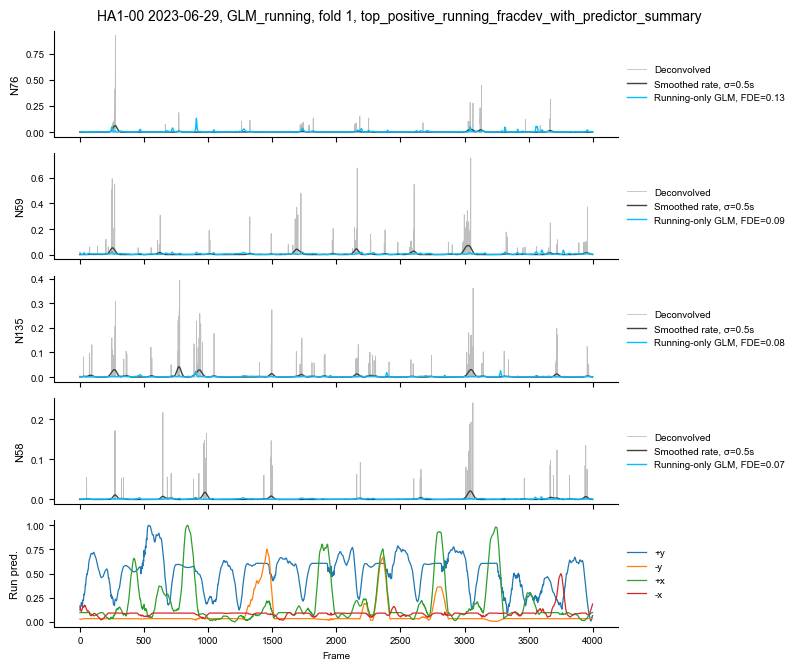

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


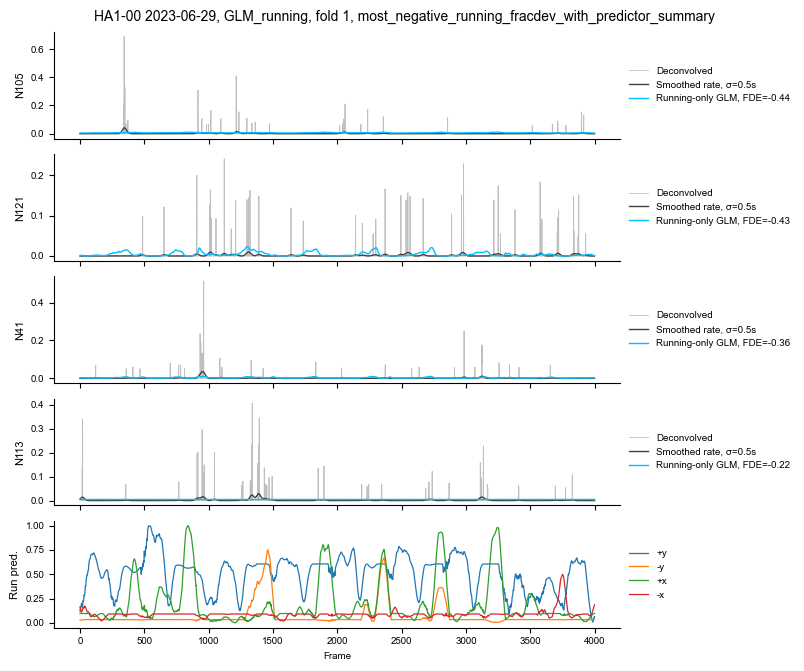

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


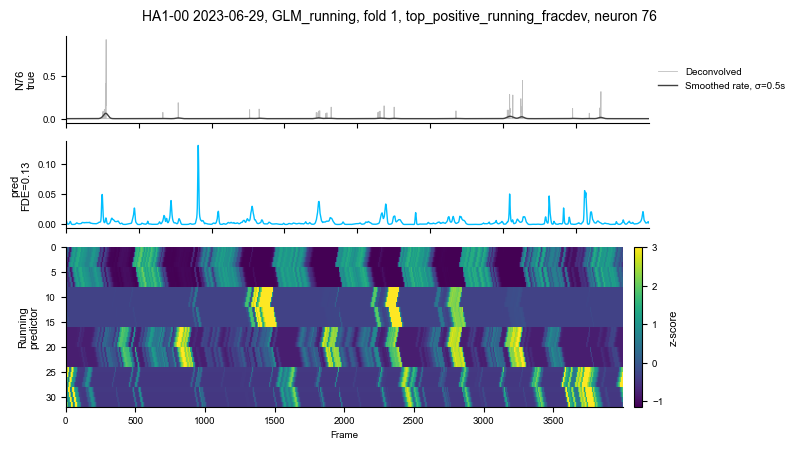

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_heatmap_N76_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


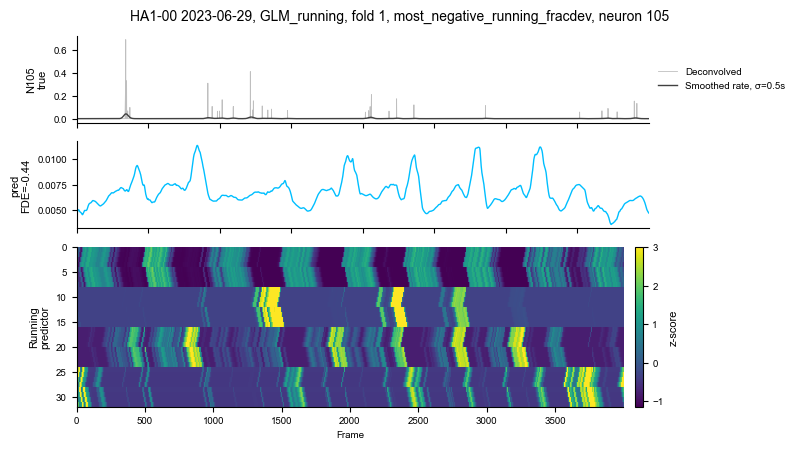

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_heatmap_N105_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


In [ ]:
# Plot running-only GLM predictions, true deconvolved activity, smoothed event rate, and running predictors
# Assumptions:
# - behav_big_matrix.mat contains variable "behav_big_matrix" with shape predictors x frames
# - combined_response.mat contains "combined_response" with shape neurons x frames
# - model y_pred has shape frames x neurons
# - frac_dev_expl has shape neurons
# - response/predictor matrices are from the same fold/test directory

import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Settings
# -----------------------------

example_dataset = mouse_dates_keys[4]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")

print("Loading from:", path)

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()
y_pred = np.asarray(fold_output['y_pred'])

# -----------------------------
# Load response and behavior
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = np.asarray(response['combined_response'])

behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = np.asarray(behav['behav_the_matrix'])

# -----------------------------
# Load raw velocity
# -----------------------------

velocity_file = scipy.io.loadmat(os.path.join(path, 'velocity.mat'))
velocity = velocity_file['velocity'] # expected shape: 2 x frames

x_velocity_raw = velocity[0, :]
y_velocity_raw = velocity[1, :]

pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

print("velocity shape, x/y x frames:", velocity.shape)


supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)

# Change these if desired
n_examples = 4
plot_windows = [(0, 1000), (1000, 2000), (2000, 3000)]
make_heatmaps = True

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# -----------------------------
# Helper functions
# -----------------------------

def zscore_for_display(x, axis=1, eps=1e-12):
    """
    Display-only z-score.
    For predictors x frames, use axis=1 to z-score each predictor over time.
    """
    x = x.astype(float).copy()
    mu = np.nanmean(x, axis=axis, keepdims=True)
    sigma = np.nanstd(x, axis=axis, keepdims=True)
    sigma[sigma < eps] = 1.0
    return (x - mu) / sigma


def minmax_for_display(x, eps=1e-12):
    """
    Display-only min-max scaling to 0-1.
    """
    x = x.astype(float).copy()
    x = x - np.nanmin(x)
    denom = np.nanmax(x)
    if denom < eps:
        denom = 1.0
    return x / denom


def plot_neurons_with_running_summary(neuron_ids, frame_start, frame_end, label):
    """
    Plot true deconvolved activity, smoothed deconvolved rate,
    running-only prediction, and a compact running predictor magnitude trace.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    n_rows = len(neuron_ids) + 1

    fig, axs = plt.subplots(
        n_rows,
        1,
        figsize=(8, 1.35 * n_rows),
        sharex=True
    )

    if n_rows == 1:
        axs = [axs]

    for i, neuron_idx in enumerate(neuron_ids):
        ax = axs[i]

        true_y = response_matrix[neuron_idx, frames]
        pred_y = y_pred[frames, neuron_idx]

        ax.plot(
            frames,
            true_y,
            color=[0.75, 0.75, 0.75],
            linewidth=0.6,
            label='Deconvolved'
        )

        if plot_smoothed_rate:
            true_rate = gaussian_filter1d(
                true_y.astype(float),
                sigma=smooth_sigma_frames,
                mode='nearest'
            )

            ax.plot(
                frames,
                true_rate,
                color=[0.25, 0.25, 0.25],
                linewidth=1.0,
                label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
            )

        ax.plot(
            frames,
            pred_y,
            color='deepskyblue',
            linewidth=1.0,
            label=f'Running-only GLM, FDE={frac_dev_expl[neuron_idx]:.2f}'
        )

        ax.set_ylabel(f'N{neuron_idx}', fontsize=8)
        ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Running predictor summary
    ax = axs[-1]

    for group_name, group_trace in running_group_summaries.items():
        ax.plot(
            frames,
            group_trace[frames],
            linewidth=0.9,
            label=group_name
        )

    ax.set_ylabel('Run pred.\ngroups', fontsize=8)

    # ax.plot(
    #     frames,
    #     running_summary_display[frames],
    #     color=[0.2, 0.2, 0.2],
    #     linewidth=0.9,
    #     label='Running predictor magnitude'
    # )

    ax.set_ylabel('Run pred.', fontsize=8)
    ax.set_xlabel('Frame')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


def plot_neuron_with_running_predictor_heatmap(neuron_idx, frame_start, frame_end, label):
    """
    Plot one neuron with true activity, optional smoothed rate, prediction,
    and all 32 running predictors as a heatmap.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    pred_display = zscore_for_display(running_predictors[:, frames], axis=1)

    # Optional clipping makes the heatmap easier to view
    pred_display = np.clip(pred_display, -3, 3)

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(8, 4.5),
        sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.2, 2.2]}
    )

    true_y = response_matrix[neuron_idx, frames]

    axs[0].plot(
        frames,
        true_y,
        color=[0.75, 0.75, 0.75],
        linewidth=0.6,
        label='Deconvolved'
    )

    if plot_smoothed_rate:
        true_rate = gaussian_filter1d(
            true_y.astype(float),
            sigma=smooth_sigma_frames,
            mode='nearest'
        )

        axs[0].plot(
            frames,
            true_rate,
            color=[0.25, 0.25, 0.25],
            linewidth=1.0,
            label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
        )

        axs[0].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    axs[0].set_ylabel(f'N{neuron_idx}\ntrue', fontsize=8)

    axs[1].plot(
        frames,
        y_pred[frames, neuron_idx],
        color='deepskyblue',
        linewidth=1.0
    )
    axs[1].set_ylabel(f'pred\nFDE={frac_dev_expl[neuron_idx]:.2f}', fontsize=8)

    im = axs[2].imshow(
        pred_display,
        aspect='auto',
        interpolation='nearest',
        extent=[frames[0], frames[-1], running_predictors.shape[0], 0]
    )

    axs[2].set_ylabel('Running\npredictor', fontsize=8)
    axs[2].set_xlabel('Frame')

    cbar = plt.colorbar(im, ax=axs[2], fraction=0.025, pad=0.02)
    cbar.set_label('z-score', fontsize=8)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}, neuron {neuron_idx}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_heatmap_N{neuron_idx}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


# -----------------------------
# Load data
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']  # neurons x frames

pred_file = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix.mat'))
running_predictors = pred_file['behav_big_matrix']  # predictors x frames

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

y_pred = fold_output['y_pred']  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

print("Path:", path)
print("response_matrix shape, neurons x frames:", response_matrix.shape)
print("y_pred shape, frames x neurons:", y_pred.shape)
print("running_predictors shape, predictors x frames:", running_predictors.shape)
print("frac_dev_expl shape:", frac_dev_expl.shape)
print(f"Smoothed rate sigma: {smooth_sigma_sec} sec = {smooth_sigma_frames:.2f} frames")

# -----------------------------
# Basic shape checks
# -----------------------------

assert response_matrix.shape[0] == y_pred.shape[1], (
    f"Neuron mismatch: response has {response_matrix.shape[0]} neurons, "
    f"y_pred has {y_pred.shape[1]} neurons"
)

# This can differ slightly if model dropped edge frames, so do not assert.
if response_matrix.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: frame mismatch. response has {response_matrix.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

if running_predictors.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: predictor frame mismatch. running_predictors has {running_predictors.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

# -----------------------------
# Make display-only predictor summary
# -----------------------------

# Z-score each predictor over time, then summarize absolute predictor activity
running_pred_z = zscore_for_display(running_predictors, axis=1)
predictor_groups = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}
# Z-score each predictor over time for display only
running_pred_z = zscore_for_display(running_predictors, axis=1)

# Predictor order based on MATLAB construction:
# +y retro, +y prospective, -y retro, -y prospective,
# +x retro, +x prospective, -x retro, -x prospective
predictor_groups_8 = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}

# More compact grouping by direction/sign, collapsing retro + prospective together
predictor_groups_4 = {
    '+y': np.arange(0, 8),
    '-y': np.arange(8, 16),
    '+x': np.arange(16, 24),
    '-x': np.arange(24, 32),
}

# Choose which grouping to plot
predictor_groups_to_plot = predictor_groups_4
# predictor_groups_to_plot = predictor_groups_8

running_group_summaries = {}

for group_name, group_idx in predictor_groups_to_plot.items():
    group_trace = np.nanmean(np.abs(running_pred_z[group_idx, :]), axis=0)
    running_group_summaries[group_name] = minmax_for_display(group_trace)
# running_summary = np.nanmean(np.abs(running_pred_z), axis=0)
# running_summary_display = minmax_for_display(running_summary)

# -----------------------------
# Select neurons
# -----------------------------

top_positive_neurons = np.argsort(frac_dev_expl)[::-1][:n_examples]
most_negative_neurons = np.argsort(frac_dev_expl)[:n_examples]

print("\nTop positive running FDE neurons:")
for n in top_positive_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

print("\nMost negative running FDE neurons:")
for n in most_negative_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

# -----------------------------
# Make plots
# -----------------------------
plot_windows = [(0,4000)]
for frame_start, frame_end in plot_windows:
    plot_neurons_with_running_summary(
        top_positive_neurons,
        frame_start,
        frame_end,
        label='top_positive_running_fracdev_with_predictor_summary'
    )

    plot_neurons_with_running_summary(
        most_negative_neurons,
        frame_start,
        frame_end,
        label='most_negative_running_fracdev_with_predictor_summary'
    )

# Optional heatmaps for one top positive and one most negative neuron
if make_heatmaps:
    for frame_start, frame_end in plot_windows[:1]:
        plot_neuron_with_running_predictor_heatmap(
            top_positive_neurons[0],
            frame_start,
            frame_end,
            label='top_positive_running_fracdev'
        )

        plot_neuron_with_running_predictor_heatmap(
            most_negative_neurons[0],
            frame_start,
            frame_end,
            label='most_negative_running_fracdev'
        )

Loading from: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
velocity shape, x/y x frames: (2, 25295)
Path: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
response_matrix shape, neurons x frames: (159, 25295)
y_pred shape, frames x neurons: (25295, 159)
running_predictors shape, predictors x frames: (32, 25295)
frac_dev_expl shape: (159,)
Smoothed rate sigma: 0.5 sec = 15.24 frames

Top positive running FDE neurons:
Neuron 76: FDE = 0.132
Neuron 59: FDE = 0.086
Neuron 135: FDE = 0.084
Neuron 58: FDE = 0.068

Most negative running FDE neurons:
Neuron 105: FDE = -0.436
Neuron 121: FDE = -0.433
Neuron 41: FDE = -0.355
Neuron 113: FDE = -0.223


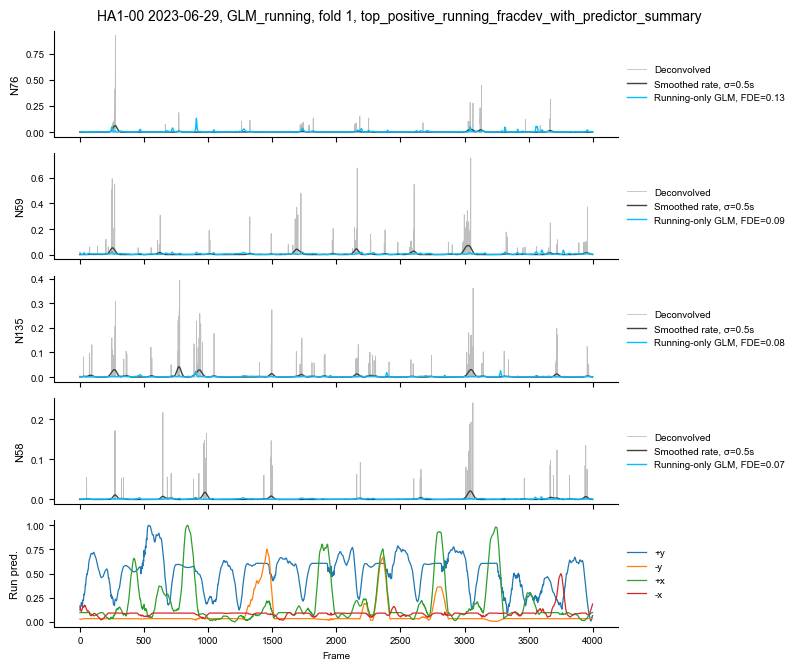

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


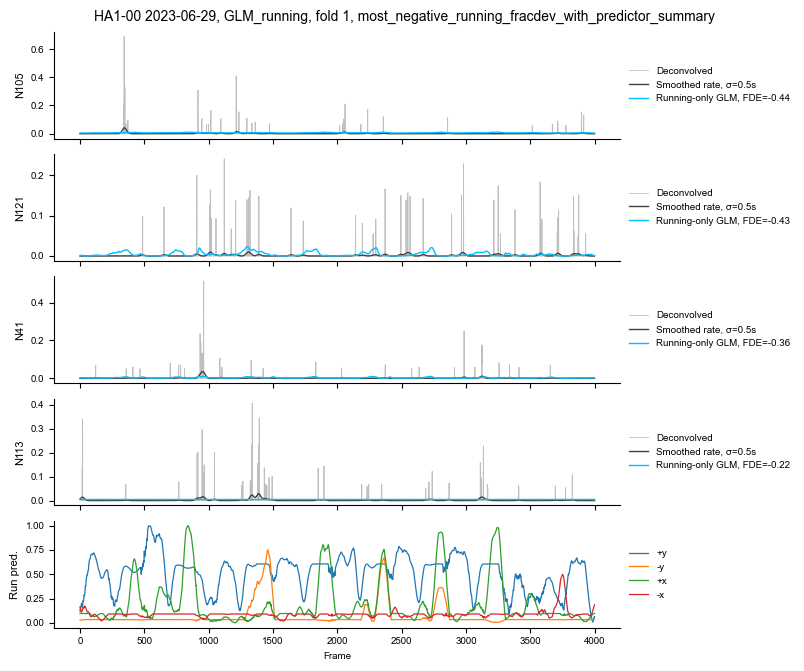

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


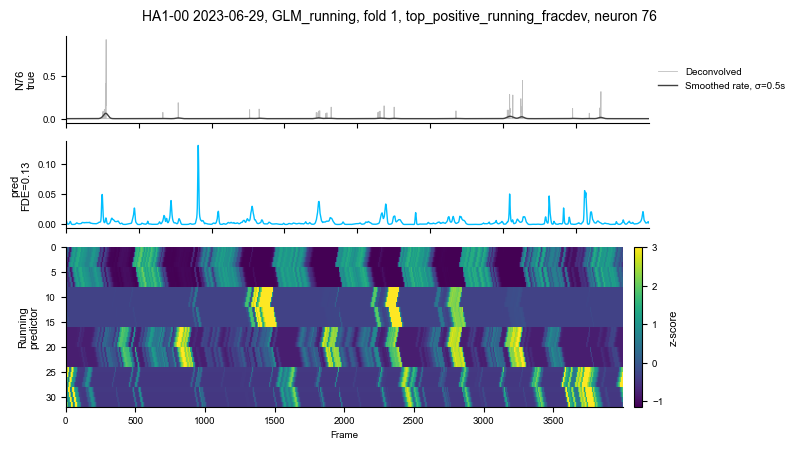

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_heatmap_N76_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


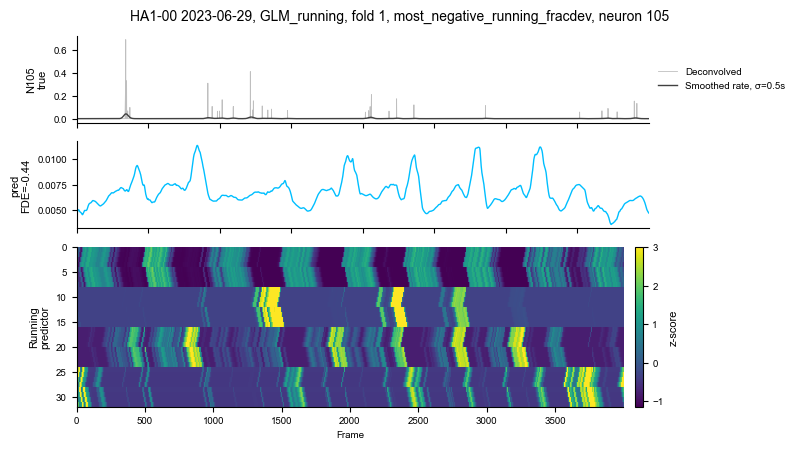

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_heatmap_N105_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


In [ ]:
# Plot running-only GLM predictions, true deconvolved activity, smoothed event rate, and running predictors
# Assumptions:
# - behav_big_matrix.mat contains variable "behav_big_matrix" with shape predictors x frames
# - combined_response.mat contains "combined_response" with shape neurons x frames
# - model y_pred has shape frames x neurons
# - frac_dev_expl has shape neurons
# - response/predictor matrices are from the same fold/test directory

import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Settings
# -----------------------------

example_dataset = mouse_dates_keys[4]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")

print("Loading from:", path)

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()
y_pred = np.asarray(fold_output['y_pred'])

# -----------------------------
# Load response and behavior
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = np.asarray(response['combined_response'])

behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = np.asarray(behav['behav_the_matrix'])

# -----------------------------
# Load raw velocity
# -----------------------------

velocity_file = scipy.io.loadmat(os.path.join(path, 'velocity.mat'))
velocity = velocity_file['velocity'] # expected shape: 2 x frames

x_velocity_raw = velocity[0, :]
y_velocity_raw = velocity[1, :]

pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

print("velocity shape, x/y x frames:", velocity.shape)


supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)

# Change these if desired
n_examples = 4
plot_windows = [(0, 1000), (1000, 2000), (2000, 3000)]
make_heatmaps = True

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# -----------------------------
# Helper functions
# -----------------------------

def zscore_for_display(x, axis=1, eps=1e-12):
    """
    Display-only z-score.
    For predictors x frames, use axis=1 to z-score each predictor over time.
    """
    x = x.astype(float).copy()
    mu = np.nanmean(x, axis=axis, keepdims=True)
    sigma = np.nanstd(x, axis=axis, keepdims=True)
    sigma[sigma < eps] = 1.0
    return (x - mu) / sigma


def minmax_for_display(x, eps=1e-12):
    """
    Display-only min-max scaling to 0-1.
    """
    x = x.astype(float).copy()
    x = x - np.nanmin(x)
    denom = np.nanmax(x)
    if denom < eps:
        denom = 1.0
    return x / denom


def plot_neurons_with_running_summary(neuron_ids, frame_start, frame_end, label):
    """
    Plot true deconvolved activity, smoothed deconvolved rate,
    running-only prediction, and a compact running predictor magnitude trace.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    n_rows = len(neuron_ids) + 1

    fig, axs = plt.subplots(
        n_rows,
        1,
        figsize=(8, 1.35 * n_rows),
        sharex=True
    )

    if n_rows == 1:
        axs = [axs]

    for i, neuron_idx in enumerate(neuron_ids):
        ax = axs[i]

        true_y = response_matrix[neuron_idx, frames]
        pred_y = y_pred[frames, neuron_idx]

        ax.plot(
            frames,
            true_y,
            color=[0.75, 0.75, 0.75],
            linewidth=0.6,
            label='Deconvolved'
        )

        if plot_smoothed_rate:
            true_rate = gaussian_filter1d(
                true_y.astype(float),
                sigma=smooth_sigma_frames,
                mode='nearest'
            )

            ax.plot(
                frames,
                true_rate,
                color=[0.25, 0.25, 0.25],
                linewidth=1.0,
                label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
            )

        ax.plot(
            frames,
            pred_y,
            color='deepskyblue',
            linewidth=1.0,
            label=f'Running-only GLM, FDE={frac_dev_expl[neuron_idx]:.2f}'
        )

        ax.set_ylabel(f'N{neuron_idx}', fontsize=8)
        ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Running predictor summary
    ax = axs[-1]

    for group_name, group_trace in running_group_summaries.items():
        ax.plot(
            frames,
            group_trace[frames],
            linewidth=0.9,
            label=group_name
        )

    ax.set_ylabel('Run pred.\ngroups', fontsize=8)

    # ax.plot(
    #     frames,
    #     running_summary_display[frames],
    #     color=[0.2, 0.2, 0.2],
    #     linewidth=0.9,
    #     label='Running predictor magnitude'
    # )

    ax.set_ylabel('Run pred.', fontsize=8)
    ax.set_xlabel('Frame')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


def plot_neuron_with_running_predictor_heatmap(neuron_idx, frame_start, frame_end, label):
    """
    Plot one neuron with true activity, optional smoothed rate, prediction,
    and all 32 running predictors as a heatmap.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    pred_display = zscore_for_display(running_predictors[:, frames], axis=1)

    # Optional clipping makes the heatmap easier to view
    pred_display = np.clip(pred_display, -3, 3)

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(8, 4.5),
        sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.2, 2.2]}
    )

    true_y = response_matrix[neuron_idx, frames]

    axs[0].plot(
        frames,
        true_y,
        color=[0.75, 0.75, 0.75],
        linewidth=0.6,
        label='Deconvolved'
    )

    if plot_smoothed_rate:
        true_rate = gaussian_filter1d(
            true_y.astype(float),
            sigma=smooth_sigma_frames,
            mode='nearest'
        )

        axs[0].plot(
            frames,
            true_rate,
            color=[0.25, 0.25, 0.25],
            linewidth=1.0,
            label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
        )

        axs[0].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    axs[0].set_ylabel(f'N{neuron_idx}\ntrue', fontsize=8)

    axs[1].plot(
        frames,
        y_pred[frames, neuron_idx],
        color='deepskyblue',
        linewidth=1.0
    )
    axs[1].set_ylabel(f'pred\nFDE={frac_dev_expl[neuron_idx]:.2f}', fontsize=8)

    im = axs[2].imshow(
        pred_display,
        aspect='auto',
        interpolation='nearest',
        extent=[frames[0], frames[-1], running_predictors.shape[0], 0]
    )

    axs[2].set_ylabel('Running\npredictor', fontsize=8)
    axs[2].set_xlabel('Frame')

    cbar = plt.colorbar(im, ax=axs[2], fraction=0.025, pad=0.02)
    cbar.set_label('z-score', fontsize=8)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}, neuron {neuron_idx}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_heatmap_N{neuron_idx}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


# -----------------------------
# Load data
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']  # neurons x frames

pred_file = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix.mat'))
running_predictors = pred_file['behav_big_matrix']  # predictors x frames

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

y_pred = fold_output['y_pred']  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

print("Path:", path)
print("response_matrix shape, neurons x frames:", response_matrix.shape)
print("y_pred shape, frames x neurons:", y_pred.shape)
print("running_predictors shape, predictors x frames:", running_predictors.shape)
print("frac_dev_expl shape:", frac_dev_expl.shape)
print(f"Smoothed rate sigma: {smooth_sigma_sec} sec = {smooth_sigma_frames:.2f} frames")

# -----------------------------
# Basic shape checks
# -----------------------------

assert response_matrix.shape[0] == y_pred.shape[1], (
    f"Neuron mismatch: response has {response_matrix.shape[0]} neurons, "
    f"y_pred has {y_pred.shape[1]} neurons"
)

# This can differ slightly if model dropped edge frames, so do not assert.
if response_matrix.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: frame mismatch. response has {response_matrix.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

if running_predictors.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: predictor frame mismatch. running_predictors has {running_predictors.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

# -----------------------------
# Make display-only predictor summary
# -----------------------------

# Z-score each predictor over time, then summarize absolute predictor activity
running_pred_z = zscore_for_display(running_predictors, axis=1)
predictor_groups = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}
# Z-score each predictor over time for display only
running_pred_z = zscore_for_display(running_predictors, axis=1)

# Predictor order based on MATLAB construction:
# +y retro, +y prospective, -y retro, -y prospective,
# +x retro, +x prospective, -x retro, -x prospective
predictor_groups_8 = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}

# More compact grouping by direction/sign, collapsing retro + prospective together
predictor_groups_4 = {
    '+y': np.arange(0, 8),
    '-y': np.arange(8, 16),
    '+x': np.arange(16, 24),
    '-x': np.arange(24, 32),
}

# Choose which grouping to plot
predictor_groups_to_plot = predictor_groups_4
# predictor_groups_to_plot = predictor_groups_8

running_group_summaries = {}

for group_name, group_idx in predictor_groups_to_plot.items():
    group_trace = np.nanmean(np.abs(running_pred_z[group_idx, :]), axis=0)
    running_group_summaries[group_name] = minmax_for_display(group_trace)
# running_summary = np.nanmean(np.abs(running_pred_z), axis=0)
# running_summary_display = minmax_for_display(running_summary)

# -----------------------------
# Select neurons
# -----------------------------

top_positive_neurons = np.argsort(frac_dev_expl)[::-1][:n_examples]
most_negative_neurons = np.argsort(frac_dev_expl)[:n_examples]

print("\nTop positive running FDE neurons:")
for n in top_positive_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

print("\nMost negative running FDE neurons:")
for n in most_negative_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

# -----------------------------
# Make plots
# -----------------------------
plot_windows = [(0,4000)]
for frame_start, frame_end in plot_windows:
    plot_neurons_with_running_summary(
        top_positive_neurons,
        frame_start,
        frame_end,
        label='top_positive_running_fracdev_with_predictor_summary'
    )

    plot_neurons_with_running_summary(
        most_negative_neurons,
        frame_start,
        frame_end,
        label='most_negative_running_fracdev_with_predictor_summary'
    )

# Optional heatmaps for one top positive and one most negative neuron
if make_heatmaps:
    for frame_start, frame_end in plot_windows[:1]:
        plot_neuron_with_running_predictor_heatmap(
            top_positive_neurons[0],
            frame_start,
            frame_end,
            label='top_positive_running_fracdev'
        )

        plot_neuron_with_running_predictor_heatmap(
            most_negative_neurons[0],
            frame_start,
            frame_end,
            label='most_negative_running_fracdev'
        )

V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_running/VR_1/test
(385, 22956)
Plotting neurons: [282 299]


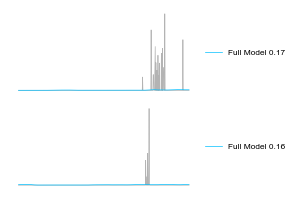

Plotting neurons: [282 299]


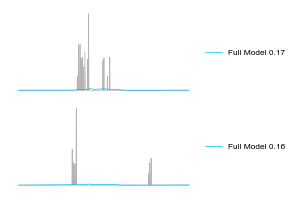

Plotting neurons: [282 299]


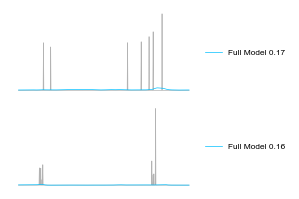

In [ ]:
# PLOT EXAMPLE NEURON PREDICTIONS VS TRUE DATA FOR BOTH MODELS FOR FOLD 1
import scipy
import os
import matplotlib.pyplot as plt
import numpy as np

plotter.default_colors_model_type = {
    'full': 'deepskyblue',
    'behav':  'mediumvioletred'} #cornflowerblue #palevioletred

example_dataset = mouse_dates_keys #[mouse_dates_keys[0]] #['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')

supp_figure_dir = f'{save_results}/example_predictions'
os.makedirs(supp_figure_dir, exist_ok=True)

#find robust neurons based on pre or passive

fold_number = 0
model_type = 'GLM_running' #'pre' or 'passive'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
model_output_all = results_pre[example_dataset[0]]['model_output_running_active']
# model_output_behav = results_pre[example_dataset[0]]['model_output_behav']

#find neurons based on pre
frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
# frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
# frac_dev_expl_behav = model_output_behav[fold_number]['frac_dev_expl']

# 1️⃣ Set thresholds
min_diff = 0.1         # minimum difference between full and behav model
min_frac_expl = 0.1     # minimum overall fraction explained
min_behav_frac = 0.0    # minimum fraction explained for behavior-only model

# 2️⃣ Mask neurons that satisfy all criteria
# mask = (frac_dev_expl_diff >= min_diff) & \
#     (frac_dev_expl >= min_frac_expl) & \
#     (frac_dev_expl_behav > min_behav_frac)

path = os.path.join(save_directory, "VR_{}/test".format(fold_number+1))
print(path)
# Load actual response data
response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']
# response_matrix[response_matrix > 0.05] = 1 #binarized result
response_matrix = response_matrix[:,:]
print(response_matrix.shape)

corrs = [np.corrcoef(model_output_all[fold_number]['y_pred'][:, i], response_matrix[i])[0, 1]
        for i in range(response_matrix.shape[0])]

# Handle any NaNs (e.g., if no variance in spike train)
correlations = np.nan_to_num(corrs, nan=0.0)

# Sort neuron indices by correlation (descending)
sorted_corr_indices = np.argsort(correlations)[::-1]
sorted_corr_values = correlations[sorted_corr_indices]
# robust_mask = (frac_dev_expl_diff > 0.05) & (correlations > 0.3)

# 3️⃣ Get indices of top neurons (sorted by frac_dev_expl within mask)
# top_indices = np.argsort(frac_dev_expl[robust_mask])[::-1]
top_indices = np.argsort(frac_dev_expl)[::-1]  # Just sort by frac_dev_expl without masking for this example

# 4️⃣ Map back to original indices
selected_neurons = top_indices #np.where(mask)[0][top_indices]
sorted_indices = selected_neurons

#load behav matrix to have some sort of trial structure
behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = behav['behav_the_matrix'] #7/8 are sounds

# Example neuron IDs to plot (replace with your specific neuron IDs)
# neuronIDs = np.random.choice(response_matrix.shape[0],4, replace = False)#[0, 1, 2, 3]  # Example list of neuron IDs
# Sort neuron IDs based on frac_dev_expl (descending)
# frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
# frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
# sorted_indices = np.argsort(frac_dev_expl_diff)[::-1]  # descending order
neuronIDs = sorted_indices[:2]  # Take top 4 [:4]
ranges = [range(i, i+500) for i in range(0, 3000, 1000)]
for frames in ranges: #[range(0,2000), range(2000,4000), range(4000,6000), range(6000,8000)]: #ranges: #
    print("Plotting neurons:", neuronIDs)
    # Create subplots for each neuron
    fig, axs = plt.subplots(len(neuronIDs), 1, figsize=(3,2), sharex=True) #(4,3) figsize=(2.3,.7)
    # Plot each neuron's y_pred for both models
    for i, neuronID in enumerate(neuronIDs):
        # Extract y_pred data for neuronID from model_output_all and model_output_behav
        real_y = response_matrix[neuronID,frames] #
        y_pred_model1 = model_output_all[fold_number]['y_pred'][frames, neuronID]
        # y_pred_model_behav = model_output_behav[fold_number]['y_pred'][frames, neuronID]
        # Plot y_pred for neuronID from both models in the i-th subplot
        # axs[i].plot(behav_matrix[7,frames],color = [0.9, 0.9, 0.9 ] , label='Sound Onset 1')
        # axs[i].plot(behav_matrix[8,frames],color = [0.8, 0.8, 0.8 ] , label='Sound Onset 2')
        axs[i].plot(real_y,color = [0.7, 0.7, 0.7 ] , linewidth=.5) #, label='Deconvolved'
        axs[i].plot(y_pred_model1, label=f"Full Model {model_output_all[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['full'] , linewidth=.5) #[0.4, 0.4, 1 ]
        # axs[i].plot(y_pred_model_behav,label=f"Partial Model {model_output_behav[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['behav'], linewidth=.5) #[0.8, 0.5, 1]
        # Set title and labels for the subplot
        # axs[i].set_title(f'Neuron {neuronID} ') # Comparison between Coupling and no Coupling Model
        # axs[i].set_xlabel('Frames')
        axs[i].set_ylabel('Prediction Value')

        # remove box for each subplot
        axs[i].spines['top'].set_visible(False)
        axs[i].spines['right'].set_visible(False)
        # axs[i].spines['bottom'].set_visible(False)
        # axs[i].spines['left'].set_visible(False)
        axs[i].axis('off')
        # Add legend to the subplot
        axs[i].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)
    # Adjust layout and display
    plt.tight_layout()
    os.chdir(supp_figure_dir)
    plt.savefig(f'ex_neurons_{neuronIDs}_{animalID}_{date}_{model_type}_fold{fold_number}_{frames[0]}to{frames[-1]}.pdf')
    plt.show()